In [1]:
# 调用包

# %%javascript 折叠命令
%matplotlib inline
# import find_motifs as fdm
from scipy import stats
import copy
import networkx as nx
from collections import Counter
from math import sqrt
from matplotlib.pyplot import MultipleLocator
from statistics import mean
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import time
import math
import json
import csv
import os
import shutil
import seaborn as sns
import numpy as np
import pandas as pd
import tempfile
# from pandas.io.json import json_normalize
from pandas.core.frame import DataFrame
import networkx as nx
from collections import deque
# 忽略警告
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
from sklearn.model_selection import train_test_split
from xgboost import plot_importance
from sklearn import preprocessing
from sklearn.utils import shuffle
#from sklearn.metrics import plot_confusion_matrix
lbl = preprocessing.LabelEncoder()
import xgboost as xgb

In [3]:
# 模体计算函数

#### 计算三节点网络模体度 ####
def motif3_1(G0):
    M3 = []
    bm = []
    
    for m in G0:
        if G0.out_degree(m) > 1:
            M3.append(G0.out_degree(m))
    for k in M3:
        bm.append(k*(k-1)/2)
    return int(sum(bm))
def motif3_2(G0):
    dm = []
    for p in G0:
        if G0.out_degree(p) > 0:
            for q in G0.successors(p):
                if G0.out_degree(q) > 0:
                    dm.append(G0.out_degree(q))
    return int(sum(dm))
#### 计算四节点网络模体度 ####
def motif4_1(network):
    M4_1 = []
    for i in network:  # 遍历网络中所有节点
        j=network.out_degree(i)
        if j > 2:  # 取所有出度大于2的节点
            M4_1.append((j - 2) * (j - 1) * j / 6)
    return int(np.sum(M4_1))  # 列表中的数值的和即为第一种模体在网络中的数量
def motif4_2(network):
    M4_2_1 = []
    M4_2_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            ss=network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的子代节点
                    M4_2_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                    M4_2_2.append(network.out_degree(j))  # 将符合条件的节点出度的值添加到列表2中
    M4_2_3 = (np.array(M4_2_1)-1) * np.array(M4_2_2) #- np.array(M4_2_2)  # 将计算的结果添加到列表3
    return sum(M4_2_3)  # 列表3的和即为第二种模体在网络中的数量
def motif4_3(network):
    M4_3 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k=network.out_degree(j)
                if k > 1:  # 取所有出度大于1的子代节点
                    M4_3.append((k - 1) * k / 2)  # 将计算得到的结果添加到列表中
    return int(np.sum(M4_3))  # 列表中的数值的和即为第三种模体在网络中的数量
def motif4_4(network):
    M4_4 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的子节点
                    for k in network.successors(j):  # 遍历符合条件的节点的二代子节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的二代子节点
                            M4_4.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表中
    return int(sum(M4_4))

#### 计算五节点网络模体度 ####
def motif5_1(network):
    M5_1 = []
    for i in network:  # 遍历网络中所有节点
        j = network.out_degree(i)
        if j > 3:  # 取所有出度大于3的节点
            M5_1.append((j - 3) * (j - 2) * (j - 1) * j / 24)
    return int(np.sum(M5_1))  # 列表中的数值的和即为模体在网络中的数量
def motif5_2(network):
    M5_2_1 = []
    M5_2_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 2:  # 取所有出度大于2的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 0:  # 取所有出度大于1的子代节点
                    M5_2_2.append(k)  # 将计算得到的结果添加到列表2中
                    M5_2_1.append(ss)
    M5_2_3 = (np.array(M5_2_1) - 1) * (np.array(M5_2_1) - 2) * np.array(M5_2_2) / 2
    return int(np.sum(M5_2_3))  # 列表3中的数值的和即为模体在网络中的数量
def motif5_3(network):
    M5_3_1 = []
    M5_3_2 = 0
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            Ms = []
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 0:  # 取所有出度大于0的子代节点
                    Ms.append(k)
            if Ms != []:
                Mas =np.array(Ms)
                ans=np.sum(np.dot(Mas[:,None],Mas[None,:]))-np.sum(Mas**2)
                M5_3_1.append(ans)  # 将计算得到的结果添加到列表中
    M5_3_2=sum(M5_3_1)/2# 列表中的数值的和即为模体在网络中的数量
    return int(M5_3_2)
def motif5_4(network):
    M5_4_1 = []
    M5_4_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 1:  # 取所有出度大于1的子代节点
                    M5_4_2.append((k - 1) * k / 2)  # 将计算得到的结果添加到列表2中
                    M5_4_1.append(ss)
    M5_4_3 = (np.array(M5_4_1) - 1) * np.array(M5_4_2)
    return int(np.sum(M5_4_3))  # 列表3中的数值的和即为模体在网络中的数量
def motif5_5(network):
    M5_5_1 = []
    M5_5_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于1的节点
                    for k in network.successors(j):  # 遍历符合条件的节点的子代节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子代节点
                            M5_5_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                            M5_5_2.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表2中
    M5_5_3 = (np.array(M5_5_1) - 1) * np.array(M5_5_2)  # - np.array(M4_3_2)  # 将计算的结果添加到列表3
    return sum(M5_5_3)  # 列表3的和即为第三种模体在网络中的数量
def motif5_5_0(network):
    M5_5_1 = []
    M5_5_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于0的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于1的节点
                    M5_5_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                    Ms = []
                    for k in network.successors(j):  # 遍历符合条件的节点的子代节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子代节点
                            Ms.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表1中
                    M5_5_2.append(sum(Ms))  # 将符合条件的节点出度的值添加到列表1中
    M5_5_3 = (np.array(M5_5_1) - 1) * np.array(M5_5_2)  # - np.array(M4_3_2)  # 将计算的结果添加到列表3
    return sum(M5_5_3)  # 列表3的和即为模体在网络中的数量
def motif5_6(network):
    M5_6 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 2:  # 取所有出度大于2的节点
                    M5_6.append((k - 2) * (k - 1) * k / 6)
    return int(np.sum(M5_6))  # 列表中的数值的和即为模体在网络中的数量
def motif5_7(network):
    M5_7_1 = []
    M5_7_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 1:  # 取所有出度大于1的节点
                    ss = network.out_degree(j)
                    for k in network.successors(j):  # 遍历符合条件的节点的子代节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子代节点
                            M5_7_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                            M5_7_2.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表2中
    M5_7_3 = (np.array(M5_7_1) - 1) * np.array(M5_7_2)  # - np.array(M4_3_2)  # 将计算的结果添加到列表3
    return sum(M5_7_3)  # 列表3的和即为模体在网络中的数量
def motif5_8(network):
    M5_8 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的节点
                    for s in network.successors(j):  # 遍历符合条件的节点的子代节点
                        k = network.out_degree(s)
                        if k > 1:  # 取所有出度大于1的子代节点
                            M5_8.append((k - 1) * k / 2)  # 将计算得到的结果添加到列表中
    return int(np.sum(M5_8))  # 列表中的数值的和即为模体在网络中的数量
def motif5_9(network):
    M5_9 = 0
    length= dict(nx.all_pairs_shortest_path_length(network))
    for i in length.values():
        a=np.array(list(i.values()))
        M5_9 += np.sum(a == 4)
    return M5_9
def motif5_9_0(network):
    M5_9 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的子节点
                    for k in network.successors(j):  # 遍历符合条件的节点的二代子节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子节点
                            for l in network.successors(k):  # 遍历符合条件的节点的三代子节点
                                if network.out_degree(l) > 0:  # 取所有出度大于0的三代子节点
                                    M5_9.append(network.out_degree(l))  # 将符合条件的节点出度的值添加到列表中

    return int(sum(M5_9))

In [41]:
import os
import pandas as pd
from pathlib import Path

# ===== 根目录（包含多个子文件夹，每个子文件夹下有 fake/real）=====
ROOT_DIR = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo')

# 可能作为 id 的列名别名（统一转小写后匹配）
ID_ALIASES = {'id', 'mid', 'tweet_id', 'status_id', 'post_id', 'weibo_id', 'uid', 'user_id'}


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """去掉列名前后空格、转小写、清理BOM等异常字符。"""
    df.columns = [str(c) for c in df.columns]
    cols = pd.Index(df.columns).str.replace('\ufeff', '', regex=False)  # 去BOM
    cols = cols.str.strip().str.lower()
    df.columns = cols
    return df


def coerce_id_column(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    """把各种 id 别名统一重命名为 id；若找不到则尝试从第一列兜底；失败时报错。"""
    df = normalize_columns(df)

    # 1) 直接命中
    if 'id' in df.columns:
        return df

    # 2) 命中别名
    hit = [c for c in df.columns if c in ID_ALIASES]
    if hit:
        df = df.rename(columns={hit[0]: 'id'})
        return df

    # 3) 第一列兜底（很多导出为 'unnamed: 0'）
    if df.columns[0].startswith('unnamed'):
        df = df.rename(columns={df.columns[0]: 'id'})
        return df

    # 4) 实在找不到，报错提示
    raise KeyError(f"[ERROR] 文件 {fname} 找不到 id 列。现有列名: {list(df.columns)[:10]} ...")


def concat_by_id(folder: Path):
    """
    对某个目录下的所有 CSV 按 id 外连接拼接：
    - 自动识别/统一 id 列；
    - 特征列 = 除“第一列”和 'id' 之外的所有列；
    - 为每个文件的特征列加上文件名前缀。
    """
    folder = Path(folder)
    if (not folder.exists()) or (not folder.is_dir()):
        print(f"[WARN] 目录不存在或不是文件夹：{folder}")
        return pd.DataFrame(columns=['id'])

    files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])

    if not files:
        print(f"[WARN] 目录中没有 CSV 文件：{folder}")
        return pd.DataFrame(columns=['id'])

    merged = None
    for fname in files:
        fpath = folder / fname
        prefix = Path(fname).stem  # 文件名前缀（不含扩展名）

        # 读入：优先 utf-8-sig，失败回退默认
        try:
            df = pd.read_csv(fpath, encoding='utf-8-sig', dtype='string')
        except UnicodeDecodeError:
            df = pd.read_csv(fpath, dtype='string')

        # 统一 id 列（同时完成列名规范化）
        df = coerce_id_column(df, fname)

        all_cols = list(df.columns)
        if not all_cols:
            print(f"[WARN] {fname} 没有有效列，已跳过。")
            continue

        # 当前文件的“第一列”（原始意义上第一列）
        first_col = all_cols[0]

        # 特征列：排除第一列以及 id 列
        feature_cols = [c for c in all_cols if c not in {first_col, 'id'}]

        if not feature_cols:
            print(f"[WARN] {fname} 除第一列和 id 以外无特征列，已跳过。现有列: {all_cols}")
            continue

        # 只保留 id + 特征列，并按 id 去重
        need = ['id'] + feature_cols
        df = df[need].drop_duplicates(subset=['id'], keep='first')

        # 给“特征列”加前缀；id 不加
        rename_map = {c: f"{prefix}_{c}" for c in feature_cols}
        df = df.rename(columns=rename_map)

        # 逐个按 id 外连接
        if merged is None:
            merged = df
        else:
            merged = merged.merge(df, on='id', how='outer')

    if merged is None:
        return pd.DataFrame(columns=['id'])

    # 按 id 排序
    merged = merged.sort_values('id', kind='stable').reset_index(drop=True)
    return merged


# ===== 遍历根目录下的每个子文件夹，分别处理 fake / real =====
for subdir in ROOT_DIR.iterdir():
    if not subdir.is_dir():
        continue

    fake_path = subdir / 'fake'
    real_path = subdir / 'real'

    if not fake_path.exists() or not real_path.exists():
        print(f"[SKIP] 子目录 {subdir} 下未找到 fake/real 子文件夹，已跳过。")
        continue

    print(f"[INFO] Processing folder: {subdir}")

    final_fake_data = concat_by_id(fake_path)
    final_real_data = concat_by_id(real_path)

    # 输出路径：直接写在当前子目录下
    output_fake_path = subdir / '拼接后的假新闻数据1.csv'
    output_real_path = subdir / '拼接后的真实新闻数据1.csv'

    final_fake_data.to_csv(output_fake_path, index=False, encoding='utf-8-sig')
    final_real_data.to_csv(output_real_path, index=False, encoding='utf-8-sig')

    print(f'  -> fake saved to {output_fake_path} | shape={final_fake_data.shape}')
    print(f'  -> real  saved to {output_real_path} | shape={final_real_data.shape}')

print("[DONE] All subfolders processed.")


[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的假新闻数据1.csv | shape=(2312, 157)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的真实新闻数据1.csv | shape=(2349, 157)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的假新闻数据1.csv | shape=(2312, 133)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的真实新闻数据1.csv | shape=(2349, 133)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv | shape=(2312, 73)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv | shape=(2349, 73)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-inter
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-inter\拼接后的假新闻数据1.csv | shape=(2312, 121)
  -> real  saved to E:\大论文-第一部分\小论文数据\消

In [43]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder
# import numpy as np
# import pandas as pd
# from pathlib import Path

# from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
# from sklearn.metrics import (
#     accuracy_score, recall_score, precision_score, f1_score,
#     roc_auc_score, average_precision_score
# )
# from sklearn.preprocessing import LabelEncoder
# from xgboost import XGBClassifier

# fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的假新闻数据1.csv'
# real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的真实新闻数据1.csv'
# out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off')
# out_dir.mkdir(parents=True, exist_ok=True)

# # 是否对真实新闻上采样（与你目前一致）
# USE_UPSAMPLE = True

# # 重复评测次数（拿固定参数做多少次随机留出评测并记录）
# R = 50

# # 是否对特征做 0-1 归一化
# USE_MINMAX = True

# # ================== 读数 & 标签 ==================
# lbl = LabelEncoder()
# fake = pd.read_csv(fake_path).copy()
# real = pd.read_csv(real_path).copy()
# fake['label'] = 1
# real['label'] = 0

# if USE_UPSAMPLE:
#     # 上采样真实新闻，保持与现有做法一致
#     real = real.sample(len(fake), replace=True, random_state=42)

# df = pd.concat([fake, real], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ================== 特征构造 ==================
# # 假定第 0 列为 id，最后一列为 label，中间为特征
# X_df = df.iloc[:, 1:-1].copy()

# if USE_MINMAX:
#     den = (X_df.max() - X_df.min())
#     X_df = (X_df - X_df.min()) / den.replace(0, 1)

# X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# X = X_df.astype(float).values
# y = df['label'].astype(int).values

# # ================== 外部留出：测试集（用于最终报告） ==================
# X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # 若不做上采样，可根据类别比例设置 scale_pos_weight
# pos = (y_train_all == 1).sum()
# neg = (y_train_all == 0).sum()
# ratio = neg / max(pos, 1)

# # ================== 固定使用的最优参数 ==================
# best_params = {
#     'subsample': 0.75,
#     'reg_lambda': 2.0,
#     'reg_alpha': 0.7,
#     'n_estimators': 1600,
#     'min_child_weight': 1,
#     'max_depth': 5,
#     'learning_rate': 0.03,
#     'gamma': 0.0,
#     'colsample_bytree': 0.85,
# }

# # 如未上采样，则建议同时设置 scale_pos_weight
# if not USE_UPSAMPLE:
#     best_params['scale_pos_weight'] = ratio

# # ================== 用固定最优参数做重复评测并写入 CSV ==================
# metrics_rows = []

# for r in range(R):
#     # 每次用不同的随机种子在训练集内部切出验证集
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train_all, y_train_all,
#         test_size=0.15,
#         stratify=y_train_all,
#         random_state=1000 + r
#     )

#     clf = XGBClassifier(
#         **best_params,
#         objective='binary:logistic',
#         tree_method='hist',
#         eval_metric='auc',
#         n_jobs=8,
#         random_state=2024 + r
#     )
#     clf.fit(X_tr, y_tr)

#     # 在验证集上搜索使 F1 最大的阈值
#     p_val  = clf.predict_proba(X_val)[:, 1]
#     ths    = np.linspace(0.05, 0.95, 19)
#     f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
#     best_t = float(ths[int(np.argmax(f1s))])

#     # 在固定外部测试集上评估
#     p_test = clf.predict_proba(X_test_all)[:, 1]
#     y_pred = (p_test >= best_t).astype(int)

#     acc = accuracy_score(y_test_all, y_pred)
#     rec = recall_score(y_test_all, y_pred)
#     pre = precision_score(y_test_all, y_pred)
#     f1  = f1_score(y_test_all, y_pred)
#     auc = roc_auc_score(y_test_all, p_test)
#     ap  = average_precision_score(y_test_all, p_test)

#     metrics_rows.append({
#         'Run': r + 1,
#         'BestThreshold': round(best_t, 4),
#         'Accuracy': round(acc, 4),
#         'Recall': round(rec, 4),
#         'Precision': round(pre, 4),
#         'F1': round(f1, 4),
#         'ROC_AUC': round(auc, 4),
#         'PR_AUC': round(ap, 4),
#     })

# # 保存每次识别性能
# runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params.csv'
# pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
# print(f"Saved per-run metrics to: {runs_csv}")

# # 打印整体均值/方差
# dfm = pd.DataFrame(metrics_rows)
# summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
# print("\n===== Aggregate over {} runs (fixed best params) =====".format(R))
# print(summary)

# summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params.csv'
# summary.to_csv(summary_out, encoding='utf-8-sig')
# print(f"Saved runs summary to: {summary_out}")

# # 记录一下这组固定参数本身
# best_summary = pd.DataFrame([best_params])
# best_summary_out = out_dir / 'xgb_best_params_fixed.csv'
# best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
# print(f"Saved fixed best-params to: {best_summary_out}")

Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\xgb_runs_metrics_fixed_best_params.csv

===== Aggregate over 50 runs (fixed best params) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.9255  0.9262     0.9253  0.9255   0.9734  0.9754
std     0.0047  0.0178     0.0158  0.0048   0.0013  0.0016
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\xgb_runs_metrics_summary_fixed_best_params.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\xgb_best_params_fixed.csv


In [45]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder
# import numpy as np
# import pandas as pd
# from pathlib import Path

# from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
# from sklearn.metrics import (
#     accuracy_score, recall_score, precision_score, f1_score,
#     roc_auc_score, average_precision_score
# )
# from sklearn.preprocessing import LabelEncoder
# from xgboost import XGBClassifier

# fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的假新闻数据1.csv'
# real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的真实新闻数据1.csv'
# out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off')
# out_dir.mkdir(parents=True, exist_ok=True)

# # 是否对真实新闻上采样（与你目前一致）
# USE_UPSAMPLE = True

# # 重复评测次数（拿固定参数做多少次随机留出评测并记录）
# R = 50

# # 是否对特征做 0-1 归一化
# USE_MINMAX = True

# # ================== 读数 & 标签 ==================
# lbl = LabelEncoder()
# fake = pd.read_csv(fake_path).copy()
# real = pd.read_csv(real_path).copy()
# fake['label'] = 1
# real['label'] = 0

# if USE_UPSAMPLE:
#     # 上采样真实新闻，保持与现有做法一致
#     real = real.sample(len(fake), replace=True, random_state=42)

# df = pd.concat([fake, real], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ================== 特征构造 ==================
# # 假定第 0 列为 id，最后一列为 label，中间为特征
# X_df = df.iloc[:, 1:-1].copy()

# if USE_MINMAX:
#     den = (X_df.max() - X_df.min())
#     X_df = (X_df - X_df.min()) / den.replace(0, 1)

# X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# X = X_df.astype(float).values
# y = df['label'].astype(int).values

# # ================== 外部留出：测试集（用于最终报告） ==================
# X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # 若不做上采样，可根据类别比例设置 scale_pos_weight
# pos = (y_train_all == 1).sum()
# neg = (y_train_all == 0).sum()
# ratio = neg / max(pos, 1)

# # ================== 固定使用的最优参数 ==================
# best_params = {
#     'subsample': 0.75,
#     'reg_lambda': 2.0,
#     'reg_alpha': 0.7,
#     'n_estimators': 1600,
#     'min_child_weight': 1,
#     'max_depth': 5,
#     'learning_rate': 0.03,
#     'gamma': 0.0,
#     'colsample_bytree': 0.85,
# }

# # 如未上采样，则建议同时设置 scale_pos_weight
# if not USE_UPSAMPLE:
#     best_params['scale_pos_weight'] = ratio

# # ================== 用固定最优参数做重复评测并写入 CSV ==================
# metrics_rows = []

# for r in range(R):
#     # 每次用不同的随机种子在训练集内部切出验证集
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train_all, y_train_all,
#         test_size=0.15,
#         stratify=y_train_all,
#         random_state=1000 + r
#     )

#     clf = XGBClassifier(
#         **best_params,
#         objective='binary:logistic',
#         tree_method='hist',
#         eval_metric='auc',
#         n_jobs=8,
#         random_state=2024 + r
#     )
#     clf.fit(X_tr, y_tr)

#     # 在验证集上搜索使 F1 最大的阈值
#     p_val  = clf.predict_proba(X_val)[:, 1]
#     ths    = np.linspace(0.05, 0.95, 19)
#     f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
#     best_t = float(ths[int(np.argmax(f1s))])

#     # 在固定外部测试集上评估
#     p_test = clf.predict_proba(X_test_all)[:, 1]
#     y_pred = (p_test >= best_t).astype(int)

#     acc = accuracy_score(y_test_all, y_pred)
#     rec = recall_score(y_test_all, y_pred)
#     pre = precision_score(y_test_all, y_pred)
#     f1  = f1_score(y_test_all, y_pred)
#     auc = roc_auc_score(y_test_all, p_test)
#     ap  = average_precision_score(y_test_all, p_test)

#     metrics_rows.append({
#         'Run': r + 1,
#         'BestThreshold': round(best_t, 4),
#         'Accuracy': round(acc, 4),
#         'Recall': round(rec, 4),
#         'Precision': round(pre, 4),
#         'F1': round(f1, 4),
#         'ROC_AUC': round(auc, 4),
#         'PR_AUC': round(ap, 4),
#     })

# # 保存每次识别性能
# runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params.csv'
# pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
# print(f"Saved per-run metrics to: {runs_csv}")

# # 打印整体均值/方差
# dfm = pd.DataFrame(metrics_rows)
# summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
# print("\n===== Aggregate over {} runs (fixed best params) =====".format(R))
# print(summary)

# summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params.csv'
# summary.to_csv(summary_out, encoding='utf-8-sig')
# print(f"Saved runs summary to: {summary_out}")

# # 记录一下这组固定参数本身
# best_summary = pd.DataFrame([best_params])
# best_summary_out = out_dir / 'xgb_best_params_fixed.csv'
# best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
# print(f"Saved fixed best-params to: {best_summary_out}")

Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\xgb_runs_metrics_fixed_best_params.csv

===== Aggregate over 50 runs (fixed best params) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.9283  0.9244     0.9321  0.9280   0.9748  0.9769
std     0.0049  0.0167     0.0172  0.0046   0.0015  0.0017
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\xgb_runs_metrics_summary_fixed_best_params.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\xgb_best_params_fixed.csv


In [47]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder
# import numpy as np
# import pandas as pd
# from pathlib import Path

# from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
# from sklearn.metrics import (
#     accuracy_score, recall_score, precision_score, f1_score,
#     roc_auc_score, average_precision_score
# )
# from sklearn.preprocessing import LabelEncoder
# from xgboost import XGBClassifier

# fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv'
# real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv'
# out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off')
# out_dir.mkdir(parents=True, exist_ok=True)

# # 是否对真实新闻上采样（与你目前一致）
# USE_UPSAMPLE = True

# # 重复评测次数（拿固定参数做多少次随机留出评测并记录）
# R = 50

# # 是否对特征做 0-1 归一化
# USE_MINMAX = True

# # ================== 读数 & 标签 ==================
# lbl = LabelEncoder()
# fake = pd.read_csv(fake_path).copy()
# real = pd.read_csv(real_path).copy()
# fake['label'] = 1
# real['label'] = 0

# if USE_UPSAMPLE:
#     # 上采样真实新闻，保持与现有做法一致
#     real = real.sample(len(fake), replace=True, random_state=42)

# df = pd.concat([fake, real], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ================== 特征构造 ==================
# # 假定第 0 列为 id，最后一列为 label，中间为特征
# X_df = df.iloc[:, 1:-1].copy()

# if USE_MINMAX:
#     den = (X_df.max() - X_df.min())
#     X_df = (X_df - X_df.min()) / den.replace(0, 1)

# X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# X = X_df.astype(float).values
# y = df['label'].astype(int).values

# # ================== 外部留出：测试集（用于最终报告） ==================
# X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # 若不做上采样，可根据类别比例设置 scale_pos_weight
# pos = (y_train_all == 1).sum()
# neg = (y_train_all == 0).sum()
# ratio = neg / max(pos, 1)

# # ================== 固定使用的最优参数 ==================
# best_params = {
#     'subsample': 0.75,
#     'reg_lambda': 2.0,
#     'reg_alpha': 0.7,
#     'n_estimators': 1600,
#     'min_child_weight': 1,
#     'max_depth': 5,
#     'learning_rate': 0.03,
#     'gamma': 0.0,
#     'colsample_bytree': 0.85,
# }

# # 如未上采样，则建议同时设置 scale_pos_weight
# if not USE_UPSAMPLE:
#     best_params['scale_pos_weight'] = ratio

# # ================== 用固定最优参数做重复评测并写入 CSV ==================
# metrics_rows = []

# for r in range(R):
#     # 每次用不同的随机种子在训练集内部切出验证集
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train_all, y_train_all,
#         test_size=0.15,
#         stratify=y_train_all,
#         random_state=1000 + r
#     )

#     clf = XGBClassifier(
#         **best_params,
#         objective='binary:logistic',
#         tree_method='hist',
#         eval_metric='auc',
#         n_jobs=8,
#         random_state=2024 + r
#     )
#     clf.fit(X_tr, y_tr)

#     # 在验证集上搜索使 F1 最大的阈值
#     p_val  = clf.predict_proba(X_val)[:, 1]
#     ths    = np.linspace(0.05, 0.95, 19)
#     f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
#     best_t = float(ths[int(np.argmax(f1s))])

#     # 在固定外部测试集上评估
#     p_test = clf.predict_proba(X_test_all)[:, 1]
#     y_pred = (p_test >= best_t).astype(int)

#     acc = accuracy_score(y_test_all, y_pred)
#     rec = recall_score(y_test_all, y_pred)
#     pre = precision_score(y_test_all, y_pred)
#     f1  = f1_score(y_test_all, y_pred)
#     auc = roc_auc_score(y_test_all, p_test)
#     ap  = average_precision_score(y_test_all, p_test)

#     metrics_rows.append({
#         'Run': r + 1,
#         'BestThreshold': round(best_t, 4),
#         'Accuracy': round(acc, 4),
#         'Recall': round(rec, 4),
#         'Precision': round(pre, 4),
#         'F1': round(f1, 4),
#         'ROC_AUC': round(auc, 4),
#         'PR_AUC': round(ap, 4),
#     })

# # 保存每次识别性能
# runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params.csv'
# pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
# print(f"Saved per-run metrics to: {runs_csv}")

# # 打印整体均值/方差
# dfm = pd.DataFrame(metrics_rows)
# summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
# print("\n===== Aggregate over {} runs (fixed best params) =====".format(R))
# print(summary)

# summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params.csv'
# summary.to_csv(summary_out, encoding='utf-8-sig')
# print(f"Saved runs summary to: {summary_out}")

# # 记录一下这组固定参数本身
# best_summary = pd.DataFrame([best_params])
# best_summary_out = out_dir / 'xgb_best_params_fixed.csv'
# best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
# print(f"Saved fixed best-params to: {best_summary_out}")

Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\xgb_runs_metrics_fixed_best_params.csv

===== Aggregate over 50 runs (fixed best params) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.9200  0.9179     0.9224  0.9197   0.9725  0.9750
std     0.0052  0.0219     0.0195  0.0054   0.0015  0.0017
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\xgb_runs_metrics_summary_fixed_best_params.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\xgb_best_params_fixed.csv


In [48]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb

# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder
# from sklearn.utils import resample

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\识别结果_4fold.csv'  # 文件名你可按需改为 5fold

# # ==============================
# # 读取与合并数据（此处不做上采样）
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# df = pd.concat([fake_data, real_data], ignore_index=True)

# # 如有 id 列，去掉（避免把纯标识符当特征）
# id_like_cols = [c for c in df.columns if c.lower() == 'id']
# if id_like_cols:
#     df = df.drop(columns=id_like_cols)

# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X_full = df1[numeric_cols].astype(float)
# y_full = df['label'].values

# # ==============================
# # 五折交叉验证
# # （上采样在每折训练集内部进行）
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X_full, y_full):
#     print(f"\n================ Fold {fold_id} ================")

#     # 划分训练 / 测试
#     X_train_full, X_test = X_full.iloc[train_index], X_full.iloc[test_index]
#     y_train_full, y_test = y_full[train_index], y_full[test_index]

#     # 将训练集拼成一个 DataFrame 方便上采样
#     train_df = X_train_full.copy()
#     train_df['label'] = y_train_full

#     # 按类别拆分
#     train_class0 = train_df[train_df['label'] == 0]
#     train_class1 = train_df[train_df['label'] == 1]

#     # 在训练集中做上采样（较少的一类采样到与较多一类相同数量）
#     if len(train_class0) < len(train_class1):
#         train_class0_up = resample(
#             train_class0,
#             replace=True,
#             n_samples=len(train_class1),
#             random_state=42
#         )
#         train_balanced = pd.concat([train_class1, train_class0_up], ignore_index=True)
#     else:
#         train_class1_up = resample(
#             train_class1,
#             replace=True,
#             n_samples=len(train_class0),
#             random_state=42
#         )
#         train_balanced = pd.concat([train_class0, train_class1_up], ignore_index=True)

#     # 打乱一下平衡后的训练集
#     train_balanced = train_balanced.sample(frac=1.0, random_state=fold_id).reset_index(drop=True)

#     X_train_bal = train_balanced.drop(columns=['label'])
#     y_train_bal = train_balanced['label'].values

#     # 再从平衡后的训练集划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_bal,
#         y_train_bal,
#         test_size=0.2,
#         stratify=y_train_bal,
#         random_state=fold_id
#     )

#     # ==============================
#     # 转换为 DMatrix
#     # ==============================
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # XGBoost 参数设置
#     # ==============================
#     params = {
#         "objective": "binary:logistic",  # 明确二分类目标
#         "eval_metric": "logloss",        # 训练监控指标，可按需改为 "auc"
#         "subsample": 0.75,
#         "reg_lambda": 2.0,
#         "reg_alpha": 0.7,
#         "min_child_weight": 1,
#         "max_depth": 5,
#         "learning_rate": 0.03,
#         "gamma": 0.0,
#         "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # 把平均结果也写入 CSV（最后一行）
# mean_row = {'Fold': 'Mean'}
# mean_row.update(mean_results.to_dict())
# results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.88, Prec=0.869, Rec=0.892, F1=0.881, AUC=0.95, AUPR=0.94

================ Fold 2 ================
Fold 2 Results: ACC=0.896, Prec=0.903, Rec=0.886, F1=0.894, AUC=0.95, AUPR=0.94

================ Fold 3 ================
Fold 3 Results: ACC=0.892, Prec=0.902, Rec=0.877, F1=0.889, AUC=0.96, AUPR=0.959

================ Fold 4 ================
Fold 4 Results: ACC=0.88, Prec=0.909, Rec=0.842, F1=0.874, AUC=0.949, AUPR=0.942

================ Fold 5 ================
Fold 5 Results: ACC=0.887, Prec=0.914, Rec=0.853, F1=0.882, AUC=0.961, AUPR=0.954

📊 五折交叉验证平均结果：
Fold         3.000
Accuracy     0.887
Recall       0.870
Precision    0.899
F1 Score     0.884
AUC          0.954
AUPR         0.947
dtype: float64

✅ 五折交叉验证结果已保存至：E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\识别结果_4fold.csv


In [61]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\识别结果_4fold.csv'

# # ==============================
# # 读取与合并数据
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# # 样本平衡
# real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
# df = pd.concat([fake_data, real_data], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X = df1[numeric_cols].astype(float)
# y = df['label'].values

# # ==============================
# # 五折交叉验证 + 训练/验证/测试划分
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X, y):
#     print(f"\n================ Fold {fold_id} ================")

#     # 测试集划分
#     X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train_full, y_test = y[train_index], y[test_index]

#     # 再从训练集中划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
#     )

#     # 转换为 DMatrix
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # 固定参数设置（与原版一致）
#     # ==============================
#     params = {
#          "subsample": 0.75,
#     "reg_lambda": 2.0,
#     "reg_alpha": 0.7,
#     "n_estimators": 1600,
#     "min_child_weight": 1,
#     "max_depth": 5,
#     "learning_rate": 0.03,
#     "gamma": 0.0,
#     "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # results_df.loc["Mean"] = ["Mean"] + mean_results.tolist()
# # results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# # print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# ==============================
# 路径设置
# ==============================
output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\拼接后的真实新闻数据1.csv'
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-3off\识别结果_4fold.csv'

# ==============================
# 读取与合并数据
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 样本平衡
real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证 + 训练/验证/测试划分
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 测试集划分
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test = y[train_index], y[test_index]

    # 再从训练集中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置
    # ==============================
    params = {
        "subsample": 0.75,
        "reg_lambda": 2.0,
        "reg_alpha": 0.7,
        "n_estimators": 1600,
        "min_child_weight": 1,
        "max_depth": 5,
        "learning_rate": 0.03,
        "gamma": 0.0,
        "colsample_bytree": 0.85
    }

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（均值 + 标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)  # pandas 默认 ddof=1

print("\n📊 五折交叉验证平均结果（Mean）：")
print(mean_results)

print("\n📈 五折交叉验证标准差（Std）：")
print(std_results)

# 也可以合成一个总览表方便看
summary_df = pd.DataFrame({
    'Mean': mean_results,
    'Std': std_results
})
print("\n📎 汇总统计（Mean ± Std）：")
print(summary_df)

# 如需保存到 CSV，可以取消下面注释
# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.932, Prec=0.927, Rec=0.937, F1=0.932, AUC=0.974, AUPR=0.97

================ Fold 2 ================
Fold 2 Results: ACC=0.921, Prec=0.918, Rec=0.924, F1=0.921, AUC=0.97, AUPR=0.97

================ Fold 3 ================
Fold 3 Results: ACC=0.919, Prec=0.92, Rec=0.918, F1=0.919, AUC=0.97, AUPR=0.965

================ Fold 4 ================
Fold 4 Results: ACC=0.914, Prec=0.934, Rec=0.89, F1=0.911, AUC=0.968, AUPR=0.956

================ Fold 5 ================
Fold 5 Results: ACC=0.921, Prec=0.926, Rec=0.916, F1=0.921, AUC=0.97, AUPR=0.965

📊 五折交叉验证平均结果（Mean）：
Fold         3.000
Accuracy     0.921
Recall       0.917
Precision    0.925
F1 Score     0.921
AUC          0.970
AUPR         0.965
dtype: float64

📈 五折交叉验证标准差（Std）：
Fold         1.581
Accuracy     0.007
Recall       0.017
Precision    0.006
F1 Score     0.007
AUC          0.002
AUPR         0.006
dtype: float64

📎 汇总统计（Mean ± Std）：
            Mean    Std
Fold  

In [63]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\识别结果_4fold.csv'

# # ==============================
# # 读取与合并数据
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# # 样本平衡
# real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
# df = pd.concat([fake_data, real_data], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X = df1[numeric_cols].astype(float)
# y = df['label'].values

# # ==============================
# # 五折交叉验证 + 训练/验证/测试划分
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X, y):
#     print(f"\n================ Fold {fold_id} ================")

#     # 测试集划分
#     X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train_full, y_test = y[train_index], y[test_index]

#     # 再从训练集中划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
#     )

#     # 转换为 DMatrix
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # 固定参数设置（与原版一致）
#     # ==============================
#     params = {
#          "subsample": 0.75,
#     "reg_lambda": 2.0,
#     "reg_alpha": 0.7,
#     "n_estimators": 1600,
#     "min_child_weight": 1,
#     "max_depth": 5,
#     "learning_rate": 0.03,
#     "gamma": 0.0,
#     "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # results_df.loc["Mean"] = ["Mean"] + mean_results.tolist()
# # results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# # print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# ==============================
# 路径设置
# ==============================
output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\拼接后的真实新闻数据1.csv'
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-4off\识别结果_4fold.csv'

# ==============================
# 读取与合并数据
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 样本平衡
real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证 + 训练/验证/测试划分
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 测试集划分
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test = y[train_index], y[test_index]

    # 再从训练集中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置
    # ==============================
    params = {
        "subsample": 0.75,
        "reg_lambda": 2.0,
        "reg_alpha": 0.7,
        "n_estimators": 1600,
        "min_child_weight": 1,
        "max_depth": 5,
        "learning_rate": 0.03,
        "gamma": 0.0,
        "colsample_bytree": 0.85
    }

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（均值 + 标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)  # pandas 默认 ddof=1

print("\n📊 五折交叉验证平均结果（Mean）：")
print(mean_results)

print("\n📈 五折交叉验证标准差（Std）：")
print(std_results)

# 也可以合成一个总览表方便看
summary_df = pd.DataFrame({
    'Mean': mean_results,
    'Std': std_results
})
print("\n📎 汇总统计（Mean ± Std）：")
print(summary_df)

# 如需保存到 CSV，可以取消下面注释
# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.933, Prec=0.941, Rec=0.924, F1=0.932, AUC=0.975, AUPR=0.97

================ Fold 2 ================
Fold 2 Results: ACC=0.928, Prec=0.919, Rec=0.937, F1=0.928, AUC=0.97, AUPR=0.969

================ Fold 3 ================
Fold 3 Results: ACC=0.919, Prec=0.922, Rec=0.916, F1=0.919, AUC=0.972, AUPR=0.967

================ Fold 4 ================
Fold 4 Results: ACC=0.914, Prec=0.936, Rec=0.887, F1=0.911, AUC=0.967, AUPR=0.953

================ Fold 5 ================
Fold 5 Results: ACC=0.915, Prec=0.921, Rec=0.907, F1=0.914, AUC=0.971, AUPR=0.967

📊 五折交叉验证平均结果（Mean）：
Fold         3.000
Accuracy     0.922
Recall       0.914
Precision    0.928
F1 Score     0.921
AUC          0.971
AUPR         0.965
dtype: float64

📈 五折交叉验证标准差（Std）：
Fold         1.581
Accuracy     0.008
Recall       0.019
Precision    0.010
F1 Score     0.009
AUC          0.003
AUPR         0.007
dtype: float64

📎 汇总统计（Mean ± Std）：
            Mean    Std
F

In [65]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\识别结果_5fold.csv'

# # ==============================
# # 读取与合并数据
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# # 样本平衡
# real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
# df = pd.concat([fake_data, real_data], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X = df1[numeric_cols].astype(float)
# y = df['label'].values

# # ==============================
# # 五折交叉验证 + 训练/验证/测试划分
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X, y):
#     print(f"\n================ Fold {fold_id} ================")

#     # 测试集划分
#     X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train_full, y_test = y[train_index], y[test_index]

#     # 再从训练集中划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
#     )

#     # 转换为 DMatrix
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # 固定参数设置（与原版一致）
#     # ==============================
#     params = {
#          "subsample": 0.75,
#     "reg_lambda": 2.0,
#     "reg_alpha": 0.7,
#     "n_estimators": 1600,
#     "min_child_weight": 1,
#     "max_depth": 5,
#     "learning_rate": 0.03,
#     "gamma": 0.0,
#     "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # results_df.loc["Mean"] = ["Mean"] + mean_results.tolist()
# # results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# # print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# ==============================
# 路径设置
# ==============================
output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv'
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\识别结果_4fold.csv'

# ==============================
# 读取与合并数据
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 样本平衡
real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证 + 训练/验证/测试划分
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 测试集划分
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test = y[train_index], y[test_index]

    # 再从训练集中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置
    # ==============================
    params = {
        "subsample": 0.75,
        "reg_lambda": 2.0,
        "reg_alpha": 0.7,
        "n_estimators": 1600,
        "min_child_weight": 1,
        "max_depth": 5,
        "learning_rate": 0.03,
        "gamma": 0.0,
        "colsample_bytree": 0.85
    }

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（均值 + 标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)  # pandas 默认 ddof=1

print("\n📊 五折交叉验证平均结果（Mean）：")
print(mean_results)

print("\n📈 五折交叉验证标准差（Std）：")
print(std_results)

# 也可以合成一个总览表方便看
summary_df = pd.DataFrame({
    'Mean': mean_results,
    'Std': std_results
})
print("\n📎 汇总统计（Mean ± Std）：")
print(summary_df)

# 如需保存到 CSV，可以取消下面注释
# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.931, Prec=0.927, Rec=0.935, F1=0.931, AUC=0.975, AUPR=0.973

================ Fold 2 ================
Fold 2 Results: ACC=0.92, Prec=0.913, Rec=0.929, F1=0.921, AUC=0.965, AUPR=0.963

================ Fold 3 ================
Fold 3 Results: ACC=0.923, Prec=0.928, Rec=0.918, F1=0.923, AUC=0.972, AUPR=0.967

================ Fold 4 ================
Fold 4 Results: ACC=0.906, Prec=0.927, Rec=0.881, F1=0.903, AUC=0.965, AUPR=0.955

================ Fold 5 ================
Fold 5 Results: ACC=0.908, Prec=0.912, Rec=0.903, F1=0.908, AUC=0.968, AUPR=0.964

📊 五折交叉验证平均结果（Mean）：
Fold         3.000
Accuracy     0.918
Recall       0.913
Precision    0.921
F1 Score     0.917
AUC          0.969
AUPR         0.964
dtype: float64

📈 五折交叉验证标准差（Std）：
Fold         1.581
Accuracy     0.011
Recall       0.022
Precision    0.008
F1 Score     0.011
AUC          0.004
AUPR         0.007
dtype: float64

📎 汇总统计（Mean ± Std）：
            Mean    Std


In [75]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\识别结果_5fold.csv'

# # ==============================
# # 读取与合并数据
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# # 样本平衡
# real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
# df = pd.concat([fake_data, real_data], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X = df1[numeric_cols].astype(float)
# y = df['label'].values

# # ==============================
# # 五折交叉验证 + 训练/验证/测试划分
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X, y):
#     print(f"\n================ Fold {fold_id} ================")

#     # 测试集划分
#     X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train_full, y_test = y[train_index], y[test_index]

#     # 再从训练集中划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
#     )

#     # 转换为 DMatrix
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # 固定参数设置（与原版一致）
#     # ==============================
#     params = {
#          "subsample": 0.75,
#     "reg_lambda": 2.0,
#     "reg_alpha": 0.7,
#     "n_estimators": 1600,
#     "min_child_weight": 1,
#     "max_depth": 5,
#     "learning_rate": 0.03,
#     "gamma": 0.0,
#     "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # results_df.loc["Mean"] = ["Mean"] + mean_results.tolist()
# # results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# # print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# ==============================
# 路径设置
# ==============================
output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-short\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-short\拼接后的真实新闻数据1.csv'
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-short\识别结果_4fold.csv'

# ==============================
# 读取与合并数据
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 样本平衡
real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证 + 训练/验证/测试划分
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 测试集划分
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test = y[train_index], y[test_index]

    # 再从训练集中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置
    # ==============================
    params = {
        "subsample": 0.75,
        "reg_lambda": 2.0,
        "reg_alpha": 0.7,
        "n_estimators": 1600,
        "min_child_weight": 1,
        "max_depth": 5,
        "learning_rate": 0.03,
        "gamma": 0.0,
        "colsample_bytree": 0.85
    }

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（均值 + 标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)  # pandas 默认 ddof=1

print("\n📊 五折交叉验证平均结果（Mean）：")
print(mean_results)

print("\n📈 五折交叉验证标准差（Std）：")
print(std_results)

# 也可以合成一个总览表方便看
summary_df = pd.DataFrame({
    'Mean': mean_results,
    'Std': std_results
})
print("\n📎 汇总统计（Mean ± Std）：")
print(summary_df)

# 如需保存到 CSV，可以取消下面注释
# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.919, Prec=0.937, Rec=0.9, F1=0.918, AUC=0.968, AUPR=0.963

================ Fold 2 ================
Fold 2 Results: ACC=0.919, Prec=0.929, Rec=0.908, F1=0.919, AUC=0.967, AUPR=0.965

================ Fold 3 ================
Fold 3 Results: ACC=0.923, Prec=0.933, Rec=0.911, F1=0.922, AUC=0.97, AUPR=0.968

================ Fold 4 ================
Fold 4 Results: ACC=0.905, Prec=0.921, Rec=0.887, F1=0.903, AUC=0.959, AUPR=0.956

================ Fold 5 ================
Fold 5 Results: ACC=0.897, Prec=0.896, Rec=0.9, F1=0.898, AUC=0.964, AUPR=0.961

📊 五折交叉验证平均结果（Mean）：
Fold         3.000
Accuracy     0.913
Recall       0.901
Precision    0.923
F1 Score     0.912
AUC          0.966
AUPR         0.963
dtype: float64

📈 五折交叉验证标准差（Std）：
Fold         1.581
Accuracy     0.011
Recall       0.009
Precision    0.016
F1 Score     0.011
AUC          0.004
AUPR         0.005
dtype: float64

📎 汇总统计（Mean ± Std）：
            Mean    Std
Fold

In [73]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\识别结果_5fold.csv'

# # ==============================
# # 读取与合并数据
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# # 样本平衡
# real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
# df = pd.concat([fake_data, real_data], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X = df1[numeric_cols].astype(float)
# y = df['label'].values

# # ==============================
# # 五折交叉验证 + 训练/验证/测试划分
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X, y):
#     print(f"\n================ Fold {fold_id} ================")

#     # 测试集划分
#     X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train_full, y_test = y[train_index], y[test_index]

#     # 再从训练集中划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
#     )

#     # 转换为 DMatrix
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # 固定参数设置（与原版一致）
#     # ==============================
#     params = {
#          "subsample": 0.75,
#     "reg_lambda": 2.0,
#     "reg_alpha": 0.7,
#     "n_estimators": 1600,
#     "min_child_weight": 1,
#     "max_depth": 5,
#     "learning_rate": 0.03,
#     "gamma": 0.0,
#     "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # results_df.loc["Mean"] = ["Mean"] + mean_results.tolist()
# # results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# # print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# ==============================
# 路径设置
# ==============================
output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-inter\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-inter\拼接后的真实新闻数据1.csv'
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-inter\识别结果_4fold.csv'

# ==============================
# 读取与合并数据
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 样本平衡
real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证 + 训练/验证/测试划分
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 测试集划分
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test = y[train_index], y[test_index]

    # 再从训练集中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置
    # ==============================
    params = {
        "subsample": 0.75,
        "reg_lambda": 2.0,
        "reg_alpha": 0.7,
        "n_estimators": 1600,
        "min_child_weight": 1,
        "max_depth": 5,
        "learning_rate": 0.03,
        "gamma": 0.0,
        "colsample_bytree": 0.85
    }

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（均值 + 标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)  # pandas 默认 ddof=1

print("\n📊 五折交叉验证平均结果（Mean）：")
print(mean_results)

print("\n📈 五折交叉验证标准差（Std）：")
print(std_results)

# 也可以合成一个总览表方便看
summary_df = pd.DataFrame({
    'Mean': mean_results,
    'Std': std_results
})
print("\n📎 汇总统计（Mean ± Std）：")
print(summary_df)

# 如需保存到 CSV，可以取消下面注释
# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.931, Prec=0.925, Rec=0.937, F1=0.931, AUC=0.974, AUPR=0.969

================ Fold 2 ================
Fold 2 Results: ACC=0.919, Prec=0.916, Rec=0.922, F1=0.919, AUC=0.966, AUPR=0.961

================ Fold 3 ================
Fold 3 Results: ACC=0.907, Prec=0.905, Rec=0.909, F1=0.907, AUC=0.966, AUPR=0.963

================ Fold 4 ================
Fold 4 Results: ACC=0.909, Prec=0.922, Rec=0.894, F1=0.908, AUC=0.963, AUPR=0.946

================ Fold 5 ================
Fold 5 Results: ACC=0.919, Prec=0.927, Rec=0.909, F1=0.918, AUC=0.97, AUPR=0.965

📊 五折交叉验证平均结果（Mean）：
Fold         3.000
Accuracy     0.917
Recall       0.914
Precision    0.919
F1 Score     0.917
AUC          0.968
AUPR         0.961
dtype: float64

📈 五折交叉验证标准差（Std）：
Fold         1.581
Accuracy     0.010
Recall       0.016
Precision    0.009
F1 Score     0.010
AUC          0.004
AUPR         0.009
dtype: float64

📎 汇总统计（Mean ± Std）：
            Mean    Std


In [71]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn import metrics
# from sklearn.preprocessing import LabelEncoder

# # ==============================
# # 路径设置
# # ==============================
# output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的假新闻数据1.csv'
# output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\拼接后的真实新闻数据1.csv'
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-5off\识别结果_5fold.csv'

# # ==============================
# # 读取与合并数据
# # ==============================
# lbl = LabelEncoder()
# fake_data = pd.read_csv(output_fake_path)
# real_data = pd.read_csv(output_real_path)

# fake_data['label'] = 1
# real_data['label'] = 0

# # 样本平衡
# real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
# df = pd.concat([fake_data, real_data], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ==============================
# # 仅对数值列归一化
# # ==============================
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = [col for col in numeric_cols if col != 'label']

# df1 = df.copy()
# df1[numeric_cols] = df[numeric_cols].apply(
#     lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
# )

# X = df1[numeric_cols].astype(float)
# y = df['label'].values

# # ==============================
# # 五折交叉验证 + 训练/验证/测试划分
# # ==============================
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# list_all_results = []

# fold_id = 1
# for train_index, test_index in kf.split(X, y):
#     print(f"\n================ Fold {fold_id} ================")

#     # 测试集划分
#     X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train_full, y_test = y[train_index], y[test_index]

#     # 再从训练集中划出验证集 (80% train / 20% val)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
#     )

#     # 转换为 DMatrix
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
#     dtest = xgb.DMatrix(X_test, label=y_test)

#     # ==============================
#     # 固定参数设置（与原版一致）
#     # ==============================
#     params = {
#          "subsample": 0.75,
#     "reg_lambda": 2.0,
#     "reg_alpha": 0.7,
#     "n_estimators": 1600,
#     "min_child_weight": 1,
#     "max_depth": 5,
#     "learning_rate": 0.03,
#     "gamma": 0.0,
#     "colsample_bytree": 0.85
#     }

#     # ==============================
#     # 模型训练 (早停基于验证集)
#     # ==============================
#     evals = [(dtrain, 'train'), (dval, 'eval')]
#     model = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=evals,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     # ==============================
#     # 测试集预测与评估
#     # ==============================
#     ypred = model.predict(dtest)
#     y_pred = (ypred >= 0.5).astype(int)

#     ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
#     Recall = round(metrics.recall_score(y_test, y_pred), 3)
#     F1 = round(metrics.f1_score(y_test, y_pred), 3)
#     Precision = round(metrics.precision_score(y_test, y_pred), 3)
#     AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
#     AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

#     list_all_results.append({
#         'Fold': fold_id,
#         'Accuracy': ACC,
#         'Recall': Recall,
#         'Precision': Precision,
#         'F1 Score': F1,
#         'AUC': AUC,
#         'AUPR': AUPR
#     })

#     print(f"Fold {fold_id} Results: "
#           f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

#     fold_id += 1

# # ==============================
# # 汇总与保存结果
# # ==============================
# results_df = pd.DataFrame(list_all_results)
# mean_results = results_df.mean(numeric_only=True).round(3)

# print("\n📊 五折交叉验证平均结果：")
# print(mean_results)

# # results_df.loc["Mean"] = ["Mean"] + mean_results.tolist()
# # results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# # print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# ==============================
# 路径设置
# ==============================
output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-long\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-long\拼接后的真实新闻数据1.csv'
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\weibo\MSTD-long\识别结果_4fold.csv'

# ==============================
# 读取与合并数据
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 样本平衡
real_data = real_data.sample(len(fake_data), replace=True, random_state=42)
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证 + 训练/验证/测试划分
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 测试集划分
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test = y[train_index], y[test_index]

    # 再从训练集中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=fold_id
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置
    # ==============================
    params = {
        "subsample": 0.75,
        "reg_lambda": 2.0,
        "reg_alpha": 0.7,
        "n_estimators": 1600,
        "min_child_weight": 1,
        "max_depth": 5,
        "learning_rate": 0.03,
        "gamma": 0.0,
        "colsample_bytree": 0.85
    }

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（均值 + 标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)  # pandas 默认 ddof=1

print("\n📊 五折交叉验证平均结果（Mean）：")
print(mean_results)

print("\n📈 五折交叉验证标准差（Std）：")
print(std_results)

# 也可以合成一个总览表方便看
summary_df = pd.DataFrame({
    'Mean': mean_results,
    'Std': std_results
})
print("\n📎 汇总统计（Mean ± Std）：")
print(summary_df)

# 如需保存到 CSV，可以取消下面注释
# results_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存至：{save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.929, Prec=0.931, Rec=0.927, F1=0.929, AUC=0.969, AUPR=0.955

================ Fold 2 ================
Fold 2 Results: ACC=0.909, Prec=0.916, Rec=0.901, F1=0.908, AUC=0.967, AUPR=0.962

================ Fold 3 ================
Fold 3 Results: ACC=0.908, Prec=0.911, Rec=0.905, F1=0.908, AUC=0.964, AUPR=0.954

================ Fold 4 ================
Fold 4 Results: ACC=0.899, Prec=0.904, Rec=0.894, F1=0.899, AUC=0.961, AUPR=0.95

================ Fold 5 ================
Fold 5 Results: ACC=0.906, Prec=0.916, Rec=0.894, F1=0.905, AUC=0.965, AUPR=0.96

📊 五折交叉验证平均结果（Mean）：
Fold         3.000
Accuracy     0.910
Recall       0.904
Precision    0.916
F1 Score     0.910
AUC          0.965
AUPR         0.956
dtype: float64

📈 五折交叉验证标准差（Std）：
Fold         1.581
Accuracy     0.011
Recall       0.014
Precision    0.010
F1 Score     0.011
AUC          0.003
AUPR         0.005
dtype: float64

📎 汇总统计（Mean ± Std）：
            Mean    Std
F

## gossipcop

In [77]:
##截止到7天
count = 0

list2 = [30, 60, 180, 600, 1800, 3600, 10800, 21600, 43200, 86400, 259200, 777600]

for b in list2:
    count = count + 1
    print(count)
    
    path6 = r'E:\U盘\时间间隔\gossipcop\from_to_t_time_时刻\false'
    path_list6=os.listdir(path6)
    list1 = []
    for filename in path_list6:
        path_csv6 = os.path.join(path6,filename)
        df = pd.read_csv(path_csv6)
        df = df[df['时刻'] <= b]
        G = nx.from_pandas_edgelist(df, 'from', 'to' ,create_using=nx.DiGraph())
        if G.number_of_nodes() <= 5000:
            list1.append([filename,  motif3_1(G), motif3_2(G), 
                      motif4_1(G), motif4_2(G), 
                      motif4_3(G), motif4_4(G),
                     ])

            name = ['id','m3_1', 'm3_2', 'm4_1', 'm4_2', 'm4_3', 'm4_4',
                ]
            test1 = pd.DataFrame(columns = name, data = list1)
            test1.to_csv(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\fake/'+str(b)+'.csv', encoding='utf-8')


count = 0
list2 = [30, 60, 180, 600, 1800, 3600, 10800, 21600, 43200, 86400, 259200, 777600]

for b in list2:
    count = count + 1
    print(count)
    
    path6 = r'E:\U盘\时间间隔\gossipcop\from_to_t_time_时刻\ture'
    path_list6=os.listdir(path6)
    list1 = []
    for filename in path_list6:
        path_csv6 = os.path.join(path6,filename)
        df = pd.read_csv(path_csv6)
        df = df[df['时刻'] <= b]
        G = nx.from_pandas_edgelist(df, 'from', 'to' ,create_using=nx.DiGraph())
        if G.number_of_nodes() <= 5000:
            list1.append([filename,  motif3_1(G), motif3_2(G), 
                      motif4_1(G), motif4_2(G), 
                      motif4_3(G), motif4_4(G),
                      ])
            name = ['id','m3_1', 'm3_2', 'm4_1', 'm4_2', 'm4_3', 'm4_4',
                ]
            test1 = pd.DataFrame(columns = name, data = list1)
            test1.to_csv(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\real/'+str(b)+'.csv', encoding='utf-8')

1
2
3
4
5
6
7
8
9
10
11
12
1
2
3
4
5
6
7
8
9
10
11
12


In [79]:
import os
import pandas as pd
from pathlib import Path

# ===== 根目录（包含多个子文件夹，每个子文件夹下有 fake/real）=====
ROOT_DIR = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop')

# 可能作为 id 的列名别名（统一转小写后匹配）
ID_ALIASES = {'id', 'mid', 'tweet_id', 'status_id', 'post_id', 'weibo_id', 'uid', 'user_id'}


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """去掉列名前后空格、转小写、清理BOM等异常字符。"""
    df.columns = [str(c) for c in df.columns]
    cols = pd.Index(df.columns).str.replace('\ufeff', '', regex=False)  # 去BOM
    cols = cols.str.strip().str.lower()
    df.columns = cols
    return df


def coerce_id_column(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    """把各种 id 别名统一重命名为 id；若找不到则尝试从第一列兜底；失败时报错。"""
    df = normalize_columns(df)

    # 1) 直接命中
    if 'id' in df.columns:
        return df

    # 2) 命中别名
    hit = [c for c in df.columns if c in ID_ALIASES]
    if hit:
        df = df.rename(columns={hit[0]: 'id'})
        return df

    # 3) 第一列兜底（很多导出为 'unnamed: 0'）
    if df.columns[0].startswith('unnamed'):
        df = df.rename(columns={df.columns[0]: 'id'})
        return df

    # 4) 实在找不到，报错提示
    raise KeyError(f"[ERROR] 文件 {fname} 找不到 id 列。现有列名: {list(df.columns)[:10]} ...")


def concat_by_id(folder: Path):
    """
    对某个目录下的所有 CSV 按 id 外连接拼接：
    - 自动识别/统一 id 列；
    - 特征列 = 除“第一列”和 'id' 之外的所有列；
    - 为每个文件的特征列加上文件名前缀。
    """
    folder = Path(folder)
    if (not folder.exists()) or (not folder.is_dir()):
        print(f"[WARN] 目录不存在或不是文件夹：{folder}")
        return pd.DataFrame(columns=['id'])

    files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])

    if not files:
        print(f"[WARN] 目录中没有 CSV 文件：{folder}")
        return pd.DataFrame(columns=['id'])

    merged = None
    for fname in files:
        fpath = folder / fname
        prefix = Path(fname).stem  # 文件名前缀（不含扩展名）

        # 读入：优先 utf-8-sig，失败回退默认
        try:
            df = pd.read_csv(fpath, encoding='utf-8-sig', dtype='string')
        except UnicodeDecodeError:
            df = pd.read_csv(fpath, dtype='string')

        # 统一 id 列（同时完成列名规范化）
        df = coerce_id_column(df, fname)

        all_cols = list(df.columns)
        if not all_cols:
            print(f"[WARN] {fname} 没有有效列，已跳过。")
            continue

        # 当前文件的“第一列”（原始意义上第一列）
        first_col = all_cols[0]

        # 特征列：排除第一列以及 id 列
        feature_cols = [c for c in all_cols if c not in {first_col, 'id'}]

        if not feature_cols:
            print(f"[WARN] {fname} 除第一列和 id 以外无特征列，已跳过。现有列: {all_cols}")
            continue

        # 只保留 id + 特征列，并按 id 去重
        need = ['id'] + feature_cols
        df = df[need].drop_duplicates(subset=['id'], keep='first')

        # 给“特征列”加前缀；id 不加
        rename_map = {c: f"{prefix}_{c}" for c in feature_cols}
        df = df.rename(columns=rename_map)

        # 逐个按 id 外连接
        if merged is None:
            merged = df
        else:
            merged = merged.merge(df, on='id', how='outer')

    if merged is None:
        return pd.DataFrame(columns=['id'])

    # 按 id 排序
    merged = merged.sort_values('id', kind='stable').reset_index(drop=True)
    return merged


# ===== 遍历根目录下的每个子文件夹，分别处理 fake / real =====
for subdir in ROOT_DIR.iterdir():
    if not subdir.is_dir():
        continue

    fake_path = subdir / 'fake'
    real_path = subdir / 'real'

    if not fake_path.exists() or not real_path.exists():
        print(f"[SKIP] 子目录 {subdir} 下未找到 fake/real 子文件夹，已跳过。")
        continue

    print(f"[INFO] Processing folder: {subdir}")

    final_fake_data = concat_by_id(fake_path)
    final_real_data = concat_by_id(real_path)

    # 输出路径：直接写在当前子目录下
    output_fake_path = subdir / '拼接后的假新闻数据1.csv'
    output_real_path = subdir / '拼接后的真实新闻数据1.csv'

    final_fake_data.to_csv(output_fake_path, index=False, encoding='utf-8-sig')
    final_real_data.to_csv(output_real_path, index=False, encoding='utf-8-sig')

    print(f'  -> fake saved to {output_fake_path} | shape={final_fake_data.shape}')
    print(f'  -> real  saved to {output_real_path} | shape={final_real_data.shape}')

print("[DONE] All subfolders processed.")


[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-3off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-3off\拼接后的假新闻数据1.csv | shape=(3684, 157)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-3off\拼接后的真实新闻数据1.csv | shape=(6945, 157)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-4off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-4off\拼接后的假新闻数据1.csv | shape=(3684, 133)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-4off\拼接后的真实新闻数据1.csv | shape=(6945, 133)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\拼接后的假新闻数据1.csv | shape=(3684, 73)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\拼接后的真实新闻数据1.csv | shape=(6945, 73)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-inter
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-inter\拼接后的假新闻数据1.csv | shape=(3684, 

In [95]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-3off\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-3off\拼接后的真实新闻数据1.csv'
save_path  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-3off')
out_dir.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 不在这里平衡，保留原始分布
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证：只在每个 fold 的训练集里处理不平衡
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 先划分出当前 fold 的 train_full / test（保持 test 原始分布）
    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    # ------------------------------
    # 在训练集内部做上采样（只平衡 train_full）
    # ------------------------------
    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    # 找到多数类和少数类
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    # 对少数类做有放回抽样，使其数量与多数类相同
    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42+ fold_id )

    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    # 打乱一下平衡后的训练集
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    # 再从“已平衡的训练集”中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置（建议补上 objective / eval_metric）
    # ==============================
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,   # 对应 learning_rate
        "lambda": 1.0, # 对应 reg_lambda
        "alpha": 0.0,  # 对应 reg_alpha
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }
    # 这里不再用 n_estimators；num_boost_round 由下面控制
    num_boost_round = 800  # 可以理解为你的 n_estimators

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估（测试集是真实分布）
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（输出均值与标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

# 计算均值和标准差
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

print("\n📊 五折交叉验证结果汇总：")
print("平均值（Mean）：")
print(mean_results)
print("\n标准差（Std）：")
print(std_results)

# 也可以合并成一个表格输出
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
print("\n📈 平均值与标准差汇总表：")
print(summary_df)

# # 如需保存到 CSV：
# summary_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存到: {save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.877, Prec=0.801, Rec=0.86, F1=0.829, AUC=0.934, AUPR=0.879

================ Fold 2 ================
Fold 2 Results: ACC=0.878, Prec=0.8, Rec=0.863, F1=0.83, AUC=0.94, AUPR=0.892

================ Fold 3 ================
Fold 3 Results: ACC=0.876, Prec=0.803, Rec=0.851, F1=0.826, AUC=0.941, AUPR=0.894

================ Fold 4 ================
Fold 4 Results: ACC=0.88, Prec=0.8, Rec=0.871, F1=0.834, AUC=0.938, AUPR=0.881

================ Fold 5 ================
Fold 5 Results: ACC=0.863, Prec=0.783, Rec=0.837, F1=0.809, AUC=0.927, AUPR=0.865

📊 五折交叉验证结果汇总：
平均值（Mean）：
Fold         3.000
Accuracy     0.875
Recall       0.856
Precision    0.797
F1 Score     0.826
AUC          0.936
AUPR         0.882
dtype: float64

标准差（Std）：
Fold         1.581
Accuracy     0.007
Recall       0.013
Precision    0.008
F1 Score     0.010
AUC          0.006
AUPR         0.012
dtype: float64

📈 平均值与标准差汇总表：
            Mean    Std
Fold       3.000

PermissionError: [Errno 13] Permission denied: 'E:\\大论文-第一部分\\小论文数据\\消融实验-新尺度\\gossipcop\\MSTD-3off'

In [99]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-4off\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-4off\拼接后的真实新闻数据1.csv'
save_path  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-4off')
out_dir.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 不在这里平衡，保留原始分布
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证：只在每个 fold 的训练集里处理不平衡
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 先划分出当前 fold 的 train_full / test（保持 test 原始分布）
    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    # ------------------------------
    # 在训练集内部做上采样（只平衡 train_full）
    # ------------------------------
    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    # 找到多数类和少数类
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    # 对少数类做有放回抽样，使其数量与多数类相同
    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 )

    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    # 打乱一下平衡后的训练集
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    # 再从“已平衡的训练集”中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置（建议补上 objective / eval_metric）
    # ==============================
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,   # 对应 learning_rate
        "lambda": 1.0, # 对应 reg_lambda
        "alpha": 0.0,  # 对应 reg_alpha
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }
    # 这里不再用 n_estimators；num_boost_round 由下面控制
    num_boost_round = 800  # 可以理解为你的 n_estimators

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估（测试集是真实分布）
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（输出均值与标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

# 计算均值和标准差
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

print("\n📊 五折交叉验证结果汇总：")
print("平均值（Mean）：")
print(mean_results)
print("\n标准差（Std）：")
print(std_results)

# 也可以合并成一个表格输出
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
print("\n📈 平均值与标准差汇总表：")
print(summary_df)

# # 如需保存到 CSV：
# summary_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存到: {save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.876, Prec=0.793, Rec=0.87, F1=0.83, AUC=0.93, AUPR=0.88

================ Fold 2 ================
Fold 2 Results: ACC=0.881, Prec=0.808, Rec=0.859, F1=0.833, AUC=0.94, AUPR=0.891

================ Fold 3 ================
Fold 3 Results: ACC=0.881, Prec=0.816, Rec=0.848, F1=0.832, AUC=0.943, AUPR=0.894

================ Fold 4 ================
Fold 4 Results: ACC=0.878, Prec=0.791, Rec=0.882, F1=0.834, AUC=0.939, AUPR=0.882

================ Fold 5 ================
Fold 5 Results: ACC=0.859, Prec=0.774, Rec=0.837, F1=0.804, AUC=0.925, AUPR=0.865

📊 五折交叉验证结果汇总：
平均值（Mean）：
Fold         3.000
Accuracy     0.875
Recall       0.859
Precision    0.796
F1 Score     0.827
AUC          0.935
AUPR         0.882
dtype: float64

标准差（Std）：
Fold         1.581
Accuracy     0.009
Recall       0.018
Precision    0.016
F1 Score     0.013
AUC          0.008
AUPR         0.011
dtype: float64

📈 平均值与标准差汇总表：
            Mean    Std
Fold       3.

In [101]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\拼接后的真实新闻数据1.csv'
save_path  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off')
out_dir.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 不在这里平衡，保留原始分布
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证：只在每个 fold 的训练集里处理不平衡
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 先划分出当前 fold 的 train_full / test（保持 test 原始分布）
    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    # ------------------------------
    # 在训练集内部做上采样（只平衡 train_full）
    # ------------------------------
    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    # 找到多数类和少数类
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    # 对少数类做有放回抽样，使其数量与多数类相同
    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)

    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    # 打乱一下平衡后的训练集
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    # 再从“已平衡的训练集”中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置（建议补上 objective / eval_metric）
    # ==============================
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,   # 对应 learning_rate
        "lambda": 1.0, # 对应 reg_lambda
        "alpha": 0.0,  # 对应 reg_alpha
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }
    # 这里不再用 n_estimators；num_boost_round 由下面控制
    num_boost_round = 800  # 可以理解为你的 n_estimators

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估（测试集是真实分布）
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（输出均值与标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

# 计算均值和标准差
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

print("\n📊 五折交叉验证结果汇总：")
print("平均值（Mean）：")
print(mean_results)
print("\n标准差（Std）：")
print(std_results)

# 也可以合并成一个表格输出
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
print("\n📈 平均值与标准差汇总表：")
print(summary_df)

# # 如需保存到 CSV：
# summary_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存到: {save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.87, Prec=0.784, Rec=0.862, F1=0.821, AUC=0.927, AUPR=0.867

================ Fold 2 ================
Fold 2 Results: ACC=0.873, Prec=0.797, Rec=0.852, F1=0.824, AUC=0.934, AUPR=0.879

================ Fold 3 ================
Fold 3 Results: ACC=0.877, Prec=0.813, Rec=0.839, F1=0.826, AUC=0.939, AUPR=0.885

================ Fold 4 ================
Fold 4 Results: ACC=0.875, Prec=0.792, Rec=0.867, F1=0.828, AUC=0.932, AUPR=0.871

================ Fold 5 ================
Fold 5 Results: ACC=0.863, Prec=0.783, Rec=0.836, F1=0.809, AUC=0.924, AUPR=0.864

📊 五折交叉验证结果汇总：
平均值（Mean）：
Fold         3.000
Accuracy     0.872
Recall       0.851
Precision    0.794
F1 Score     0.822
AUC          0.931
AUPR         0.873
dtype: float64

标准差（Std）：
Fold         1.581
Accuracy     0.005
Recall       0.014
Precision    0.012
F1 Score     0.008
AUC          0.006
AUPR         0.009
dtype: float64

📈 平均值与标准差汇总表：
            Mean    Std
Fold     

In [103]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-short\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-short\拼接后的真实新闻数据1.csv'
save_path  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-short')
out_dir.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 不在这里平衡，保留原始分布
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证：只在每个 fold 的训练集里处理不平衡
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 先划分出当前 fold 的 train_full / test（保持 test 原始分布）
    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    # ------------------------------
    # 在训练集内部做上采样（只平衡 train_full）
    # ------------------------------
    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    # 找到多数类和少数类
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    # 对少数类做有放回抽样，使其数量与多数类相同
    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)

    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    # 打乱一下平衡后的训练集
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    # 再从“已平衡的训练集”中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置（建议补上 objective / eval_metric）
    # ==============================
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,   # 对应 learning_rate
        "lambda": 1.0, # 对应 reg_lambda
        "alpha": 0.0,  # 对应 reg_alpha
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }
    # 这里不再用 n_estimators；num_boost_round 由下面控制
    num_boost_round = 800  # 可以理解为你的 n_estimators

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估（测试集是真实分布）
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（输出均值与标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

# 计算均值和标准差
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

print("\n📊 五折交叉验证结果汇总：")
print("平均值（Mean）：")
print(mean_results)
print("\n标准差（Std）：")
print(std_results)

# 也可以合并成一个表格输出
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
print("\n📈 平均值与标准差汇总表：")
print(summary_df)

# # 如需保存到 CSV：
# summary_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存到: {save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.871, Prec=0.791, Rec=0.853, F1=0.821, AUC=0.931, AUPR=0.877

================ Fold 2 ================
Fold 2 Results: ACC=0.871, Prec=0.794, Rec=0.848, F1=0.82, AUC=0.937, AUPR=0.887

================ Fold 3 ================
Fold 3 Results: ACC=0.876, Prec=0.808, Rec=0.843, F1=0.825, AUC=0.939, AUPR=0.889

================ Fold 4 ================
Fold 4 Results: ACC=0.877, Prec=0.792, Rec=0.874, F1=0.831, AUC=0.938, AUPR=0.881

================ Fold 5 ================
Fold 5 Results: ACC=0.862, Prec=0.781, Rec=0.834, F1=0.807, AUC=0.923, AUPR=0.858

📊 五折交叉验证结果汇总：
平均值（Mean）：
Fold         3.000
Accuracy     0.871
Recall       0.850
Precision    0.793
F1 Score     0.821
AUC          0.934
AUPR         0.878
dtype: float64

标准差（Std）：
Fold         1.581
Accuracy     0.006
Recall       0.015
Precision    0.010
F1 Score     0.009
AUC          0.007
AUPR         0.012
dtype: float64

📈 平均值与标准差汇总表：
            Mean    Std
Fold     

In [105]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-inter\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-inter\拼接后的真实新闻数据1.csv'
save_path  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-inter')
out_dir.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 不在这里平衡，保留原始分布
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证：只在每个 fold 的训练集里处理不平衡
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 先划分出当前 fold 的 train_full / test（保持 test 原始分布）
    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    # ------------------------------
    # 在训练集内部做上采样（只平衡 train_full）
    # ------------------------------
    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    # 找到多数类和少数类
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    # 对少数类做有放回抽样，使其数量与多数类相同
    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)

    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    # 打乱一下平衡后的训练集
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    # 再从“已平衡的训练集”中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置（建议补上 objective / eval_metric）
    # ==============================
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,   # 对应 learning_rate
        "lambda": 1.0, # 对应 reg_lambda
        "alpha": 0.0,  # 对应 reg_alpha
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }
    # 这里不再用 n_estimators；num_boost_round 由下面控制
    num_boost_round = 800  # 可以理解为你的 n_estimators

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估（测试集是真实分布）
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（输出均值与标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

# 计算均值和标准差
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

print("\n📊 五折交叉验证结果汇总：")
print("平均值（Mean）：")
print(mean_results)
print("\n标准差（Std）：")
print(std_results)

# 也可以合并成一个表格输出
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
print("\n📈 平均值与标准差汇总表：")
print(summary_df)

# # 如需保存到 CSV：
# summary_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存到: {save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.869, Prec=0.782, Rec=0.864, F1=0.821, AUC=0.924, AUPR=0.868

================ Fold 2 ================
Fold 2 Results: ACC=0.87, Prec=0.79, Rec=0.849, F1=0.819, AUC=0.937, AUPR=0.885

================ Fold 3 ================
Fold 3 Results: ACC=0.875, Prec=0.804, Rec=0.845, F1=0.824, AUC=0.936, AUPR=0.882

================ Fold 4 ================
Fold 4 Results: ACC=0.874, Prec=0.787, Rec=0.875, F1=0.829, AUC=0.932, AUPR=0.87

================ Fold 5 ================
Fold 5 Results: ACC=0.86, Prec=0.778, Rec=0.834, F1=0.805, AUC=0.923, AUPR=0.86

📊 五折交叉验证结果汇总：
平均值（Mean）：
Fold         3.000
Accuracy     0.870
Recall       0.853
Precision    0.788
F1 Score     0.820
AUC          0.930
AUPR         0.873
dtype: float64

标准差（Std）：
Fold         1.581
Accuracy     0.006
Recall       0.016
Precision    0.010
F1 Score     0.009
AUC          0.007
AUPR         0.010
dtype: float64

📈 平均值与标准差汇总表：
            Mean    Std
Fold       3.

In [107]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

output_fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-long\拼接后的假新闻数据1.csv'
output_real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-long\拼接后的真实新闻数据1.csv'
save_path  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-long')
out_dir.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

# 不在这里平衡，保留原始分布
df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ==============================
# 仅对数值列归一化
# ==============================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

# ==============================
# 五折交叉验证：只在每个 fold 的训练集里处理不平衡
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    # 先划分出当前 fold 的 train_full / test（保持 test 原始分布）
    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    # ------------------------------
    # 在训练集内部做上采样（只平衡 train_full）
    # ------------------------------
    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    # 找到多数类和少数类
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    # 对少数类做有放回抽样，使其数量与多数类相同
    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)

    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    # 打乱一下平衡后的训练集
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    # 再从“已平衡的训练集”中划出验证集 (80% train / 20% val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    # 转换为 DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # ==============================
    # 固定参数设置（建议补上 objective / eval_metric）
    # ==============================
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,   # 对应 learning_rate
        "lambda": 1.0, # 对应 reg_lambda
        "alpha": 0.0,  # 对应 reg_alpha
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }
    # 这里不再用 n_estimators；num_boost_round 由下面控制
    num_boost_round = 800  # 可以理解为你的 n_estimators

    # ==============================
    # 模型训练 (早停基于验证集)
    # ==============================
    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # ==============================
    # 测试集预测与评估（测试集是真实分布）
    # ==============================
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    ACC = round(metrics.accuracy_score(y_test, y_pred), 3)
    Recall = round(metrics.recall_score(y_test, y_pred), 3)
    F1 = round(metrics.f1_score(y_test, y_pred), 3)
    Precision = round(metrics.precision_score(y_test, y_pred), 3)
    AUC = round(metrics.roc_auc_score(y_test, ypred), 3)
    AUPR = round(metrics.average_precision_score(y_test, ypred), 3)

    list_all_results.append({
        'Fold': fold_id,
        'Accuracy': ACC,
        'Recall': Recall,
        'Precision': Precision,
        'F1 Score': F1,
        'AUC': AUC,
        'AUPR': AUPR
    })

    print(f"Fold {fold_id} Results: "
          f"ACC={ACC}, Prec={Precision}, Rec={Recall}, F1={F1}, AUC={AUC}, AUPR={AUPR}")

    fold_id += 1

# ==============================
# 汇总与保存结果（输出均值与标准差）
# ==============================
results_df = pd.DataFrame(list_all_results)

# 计算均值和标准差
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

print("\n📊 五折交叉验证结果汇总：")
print("平均值（Mean）：")
print(mean_results)
print("\n标准差（Std）：")
print(std_results)

# 也可以合并成一个表格输出
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
print("\n📈 平均值与标准差汇总表：")
print(summary_df)

# # 如需保存到 CSV：
# summary_df.to_csv(save_path, index=False, encoding='utf-8-sig')
# print(f"\n✅ 五折交叉验证结果已保存到: {save_path}")



================ Fold 1 ================
Fold 1 Results: ACC=0.857, Prec=0.761, Rec=0.858, F1=0.806, AUC=0.908, AUPR=0.818

================ Fold 2 ================
Fold 2 Results: ACC=0.863, Prec=0.766, Rec=0.868, F1=0.814, AUC=0.917, AUPR=0.823

================ Fold 3 ================
Fold 3 Results: ACC=0.852, Prec=0.768, Rec=0.822, F1=0.794, AUC=0.911, AUPR=0.819

================ Fold 4 ================
Fold 4 Results: ACC=0.858, Prec=0.755, Rec=0.877, F1=0.811, AUC=0.913, AUPR=0.812

================ Fold 5 ================
Fold 5 Results: ACC=0.842, Prec=0.747, Rec=0.823, F1=0.783, AUC=0.904, AUPR=0.807

📊 五折交叉验证结果汇总：
平均值（Mean）：
Fold         3.000
Accuracy     0.854
Recall       0.850
Precision    0.759
F1 Score     0.802
AUC          0.911
AUPR         0.816
dtype: float64

标准差（Std）：
Fold         1.581
Accuracy     0.008
Recall       0.026
Precision    0.009
F1 Score     0.013
AUC          0.005
AUPR         0.006
dtype: float64

📈 平均值与标准差汇总表：
            Mean    Std
Fold    

## politifact

In [109]:
import os
import pandas as pd
from pathlib import Path

# ===== 根目录（包含多个子文件夹，每个子文件夹下有 fake/real）=====
ROOT_DIR = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact')

# 可能作为 id 的列名别名（统一转小写后匹配）
ID_ALIASES = {'id', 'mid', 'tweet_id', 'status_id', 'post_id', 'weibo_id', 'uid', 'user_id'}


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """去掉列名前后空格、转小写、清理BOM等异常字符。"""
    df.columns = [str(c) for c in df.columns]
    cols = pd.Index(df.columns).str.replace('\ufeff', '', regex=False)  # 去BOM
    cols = cols.str.strip().str.lower()
    df.columns = cols
    return df


def coerce_id_column(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    """把各种 id 别名统一重命名为 id；若找不到则尝试从第一列兜底；失败时报错。"""
    df = normalize_columns(df)

    # 1) 直接命中
    if 'id' in df.columns:
        return df

    # 2) 命中别名
    hit = [c for c in df.columns if c in ID_ALIASES]
    if hit:
        df = df.rename(columns={hit[0]: 'id'})
        return df

    # 3) 第一列兜底（很多导出为 'unnamed: 0'）
    if df.columns[0].startswith('unnamed'):
        df = df.rename(columns={df.columns[0]: 'id'})
        return df

    # 4) 实在找不到，报错提示
    raise KeyError(f"[ERROR] 文件 {fname} 找不到 id 列。现有列名: {list(df.columns)[:10]} ...")


def concat_by_id(folder: Path):
    """
    对某个目录下的所有 CSV 按 id 外连接拼接：
    - 自动识别/统一 id 列；
    - 特征列 = 除“第一列”和 'id' 之外的所有列；
    - 为每个文件的特征列加上文件名前缀。
    """
    folder = Path(folder)
    if (not folder.exists()) or (not folder.is_dir()):
        print(f"[WARN] 目录不存在或不是文件夹：{folder}")
        return pd.DataFrame(columns=['id'])

    files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])

    if not files:
        print(f"[WARN] 目录中没有 CSV 文件：{folder}")
        return pd.DataFrame(columns=['id'])

    merged = None
    for fname in files:
        fpath = folder / fname
        prefix = Path(fname).stem  # 文件名前缀（不含扩展名）

        # 读入：优先 utf-8-sig，失败回退默认
        try:
            df = pd.read_csv(fpath, encoding='utf-8-sig', dtype='string')
        except UnicodeDecodeError:
            df = pd.read_csv(fpath, dtype='string')

        # 统一 id 列（同时完成列名规范化）
        df = coerce_id_column(df, fname)

        all_cols = list(df.columns)
        if not all_cols:
            print(f"[WARN] {fname} 没有有效列，已跳过。")
            continue

        # 当前文件的“第一列”（原始意义上第一列）
        first_col = all_cols[0]

        # 特征列：排除第一列以及 id 列
        feature_cols = [c for c in all_cols if c not in {first_col, 'id'}]

        if not feature_cols:
            print(f"[WARN] {fname} 除第一列和 id 以外无特征列，已跳过。现有列: {all_cols}")
            continue

        # 只保留 id + 特征列，并按 id 去重
        need = ['id'] + feature_cols
        df = df[need].drop_duplicates(subset=['id'], keep='first')

        # 给“特征列”加前缀；id 不加
        rename_map = {c: f"{prefix}_{c}" for c in feature_cols}
        df = df.rename(columns=rename_map)

        # 逐个按 id 外连接
        if merged is None:
            merged = df
        else:
            merged = merged.merge(df, on='id', how='outer')

    if merged is None:
        return pd.DataFrame(columns=['id'])

    # 按 id 排序
    merged = merged.sort_values('id', kind='stable').reset_index(drop=True)
    return merged


# ===== 遍历根目录下的每个子文件夹，分别处理 fake / real =====
for subdir in ROOT_DIR.iterdir():
    if not subdir.is_dir():
        continue

    fake_path = subdir / 'fake'
    real_path = subdir / 'real'

    if not fake_path.exists() or not real_path.exists():
        print(f"[SKIP] 子目录 {subdir} 下未找到 fake/real 子文件夹，已跳过。")
        continue

    print(f"[INFO] Processing folder: {subdir}")

    final_fake_data = concat_by_id(fake_path)
    final_real_data = concat_by_id(real_path)

    # 输出路径：直接写在当前子目录下
    output_fake_path = subdir / '拼接后的假新闻数据1.csv'
    output_real_path = subdir / '拼接后的真实新闻数据1.csv'

    final_fake_data.to_csv(output_fake_path, index=False, encoding='utf-8-sig')
    final_real_data.to_csv(output_real_path, index=False, encoding='utf-8-sig')

    print(f'  -> fake saved to {output_fake_path} | shape={final_fake_data.shape}')
    print(f'  -> real  saved to {output_real_path} | shape={final_real_data.shape}')

print("[DONE] All subfolders processed.")


[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\拼接后的假新闻数据1.csv | shape=(350, 157)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\拼接后的真实新闻数据1.csv | shape=(277, 157)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\拼接后的假新闻数据1.csv | shape=(350, 133)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\拼接后的真实新闻数据1.csv | shape=(277, 133)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\拼接后的假新闻数据1.csv | shape=(350, 73)
  -> real  saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\拼接后的真实新闻数据1.csv | shape=(277, 73)
[INFO] Processing folder: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter
  -> fake saved to E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter\拼接后的假新闻数据1.csv | shape=(3

In [111]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# ================== 路径 & 基本配置 ==================
fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\拼接后的假新闻数据1.csv'
real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\拼接后的真实新闻数据1.csv'

out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off')
out_dir.mkdir(parents=True, exist_ok=True)

# 是否对真实新闻上采样（与你“最优***************保留”一致）
USE_UPSAMPLE = True

# 重复评测次数
R = 50

# 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
USE_MINMAX = True

# ================== 读数 & 标签 ==================
lbl = LabelEncoder()
fake = pd.read_csv(fake_path).copy()
real = pd.read_csv(real_path).copy()

fake['label'] = 1
real['label'] = 0

if USE_UPSAMPLE:
    # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
    real = real.sample(len(fake), replace=True, random_state=42)

df = pd.concat([fake, real], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ================== 特征构造 ==================
# 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
X_df = df.iloc[:, 1:-1].copy()

if USE_MINMAX:
    den = (X_df.max() - X_df.min())
    X_df = (X_df - X_df.min()) / den.replace(0, 1)

X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X = X_df.astype(float).values
y = df['label'].astype(int).values

# ================== 外部留出：固定测试集 ==================
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 若不做上采样，可根据类别比例设置 scale_pos_weight
pos = (y_train_all == 1).sum()
neg = (y_train_all == 0).sum()
ratio = neg / max(pos, 1)

# ================== 固定使用的最优参数（与你那段完全相同） ==================
best_params = {
    'subsample': 0.75,
    'reg_lambda': 2.0,
    'reg_alpha': 0.7,
    'n_estimators': 1600,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.0,
    'colsample_bytree': 0.85,
}

# 如未上采样，则建议同时设置 scale_pos_weight
if not USE_UPSAMPLE:
    best_params['scale_pos_weight'] = ratio

# ================== 用固定最优参数做重复评测 ==================
metrics_rows = []

for r in range(R):
    # 每次用不同的随机种子在“训练集内部”切出验证集（外部测试集固定）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.15,
        stratify=y_train_all,
        random_state=1000 + r
    )

    clf = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        n_jobs=8,
        random_state=2024 + r
    )
    clf.fit(X_tr, y_tr)

    # 在验证集上搜索使 F1 最大的阈值
    p_val  = clf.predict_proba(X_val)[:, 1]
    ths    = np.linspace(0.05, 0.95, 19)
    f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
    best_t = float(ths[int(np.argmax(f1s))])

    # 在固定外部测试集上评估
    p_test = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (p_test >= best_t).astype(int)

    acc = accuracy_score(y_test_all, y_pred)
    rec = recall_score(y_test_all, y_pred)
    pre = precision_score(y_test_all, y_pred)
    f1  = f1_score(y_test_all, y_pred)
    auc = roc_auc_score(y_test_all, p_test)
    ap  = average_precision_score(y_test_all, p_test)

    metrics_rows.append({
        'Run': r + 1,
        'BestThreshold': round(best_t, 4),
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC': round(ap, 4),
    })

# ================== 保存结果 ==================
runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
print(f"Saved per-run metrics to: {runs_csv}")

# 打印整体均值/方差
dfm = pd.DataFrame(metrics_rows)
summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
print(summary)

summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
summary.to_csv(summary_out, encoding='utf-8-sig')
print(f"Saved runs summary to: {summary_out}")

# 记录这组固定参数
best_summary = pd.DataFrame([best_params])
best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
print(f"Saved fixed best-params to: {best_summary_out}")


Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.8311  0.8394     0.8294  0.8311   0.9017  0.9093
std     0.0223  0.0758     0.0356  0.0304   0.0089  0.0092
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-3off\xgb_best_params_fixed_politifact_34.csv


In [113]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# ================== 路径 & 基本配置 ==================
fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\拼接后的假新闻数据1.csv'
real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\拼接后的真实新闻数据1.csv'

out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off')
out_dir.mkdir(parents=True, exist_ok=True)

# 是否对真实新闻上采样（与你“最优***************保留”一致）
USE_UPSAMPLE = True

# 重复评测次数
R = 50

# 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
USE_MINMAX = True

# ================== 读数 & 标签 ==================
lbl = LabelEncoder()
fake = pd.read_csv(fake_path).copy()
real = pd.read_csv(real_path).copy()

fake['label'] = 1
real['label'] = 0

if USE_UPSAMPLE:
    # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
    real = real.sample(len(fake), replace=True, random_state=42)

df = pd.concat([fake, real], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ================== 特征构造 ==================
# 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
X_df = df.iloc[:, 1:-1].copy()

if USE_MINMAX:
    den = (X_df.max() - X_df.min())
    X_df = (X_df - X_df.min()) / den.replace(0, 1)

X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X = X_df.astype(float).values
y = df['label'].astype(int).values

# ================== 外部留出：固定测试集 ==================
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 若不做上采样，可根据类别比例设置 scale_pos_weight
pos = (y_train_all == 1).sum()
neg = (y_train_all == 0).sum()
ratio = neg / max(pos, 1)

# ================== 固定使用的最优参数（与你那段完全相同） ==================
best_params = {
    'subsample': 0.75,
    'reg_lambda': 2.0,
    'reg_alpha': 0.7,
    'n_estimators': 1600,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.0,
    'colsample_bytree': 0.85,
}

# 如未上采样，则建议同时设置 scale_pos_weight
if not USE_UPSAMPLE:
    best_params['scale_pos_weight'] = ratio

# ================== 用固定最优参数做重复评测 ==================
metrics_rows = []

for r in range(R):
    # 每次用不同的随机种子在“训练集内部”切出验证集（外部测试集固定）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.15,
        stratify=y_train_all,
        random_state=1000 + r
    )

    clf = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        n_jobs=8,
        random_state=2024 + r
    )
    clf.fit(X_tr, y_tr)

    # 在验证集上搜索使 F1 最大的阈值
    p_val  = clf.predict_proba(X_val)[:, 1]
    ths    = np.linspace(0.05, 0.95, 19)
    f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
    best_t = float(ths[int(np.argmax(f1s))])

    # 在固定外部测试集上评估
    p_test = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (p_test >= best_t).astype(int)

    acc = accuracy_score(y_test_all, y_pred)
    rec = recall_score(y_test_all, y_pred)
    pre = precision_score(y_test_all, y_pred)
    f1  = f1_score(y_test_all, y_pred)
    auc = roc_auc_score(y_test_all, p_test)
    ap  = average_precision_score(y_test_all, p_test)

    metrics_rows.append({
        'Run': r + 1,
        'BestThreshold': round(best_t, 4),
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC': round(ap, 4),
    })

# ================== 保存结果 ==================
runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
print(f"Saved per-run metrics to: {runs_csv}")

# 打印整体均值/方差
dfm = pd.DataFrame(metrics_rows)
summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
print(summary)

summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
summary.to_csv(summary_out, encoding='utf-8-sig')
print(f"Saved runs summary to: {summary_out}")

# 记录这组固定参数
best_summary = pd.DataFrame([best_params])
best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
print(f"Saved fixed best-params to: {best_summary_out}")


Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.8303  0.8443     0.8249  0.8313   0.9013  0.9086
std     0.0209  0.0744     0.0348  0.0288   0.0097  0.0094
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-4off\xgb_best_params_fixed_politifact_34.csv


In [115]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# ================== 路径 & 基本配置 ==================
fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\拼接后的假新闻数据1.csv'
real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\拼接后的真实新闻数据1.csv'

out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off')
out_dir.mkdir(parents=True, exist_ok=True)

# 是否对真实新闻上采样（与你“最优***************保留”一致）
USE_UPSAMPLE = True

# 重复评测次数
R = 50

# 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
USE_MINMAX = True

# ================== 读数 & 标签 ==================
lbl = LabelEncoder()
fake = pd.read_csv(fake_path).copy()
real = pd.read_csv(real_path).copy()

fake['label'] = 1
real['label'] = 0

if USE_UPSAMPLE:
    # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
    real = real.sample(len(fake), replace=True, random_state=42)

df = pd.concat([fake, real], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ================== 特征构造 ==================
# 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
X_df = df.iloc[:, 1:-1].copy()

if USE_MINMAX:
    den = (X_df.max() - X_df.min())
    X_df = (X_df - X_df.min()) / den.replace(0, 1)

X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X = X_df.astype(float).values
y = df['label'].astype(int).values

# ================== 外部留出：固定测试集 ==================
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 若不做上采样，可根据类别比例设置 scale_pos_weight
pos = (y_train_all == 1).sum()
neg = (y_train_all == 0).sum()
ratio = neg / max(pos, 1)

# ================== 固定使用的最优参数（与你那段完全相同） ==================
best_params = {
    'subsample': 0.75,
    'reg_lambda': 2.0,
    'reg_alpha': 0.7,
    'n_estimators': 1600,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.0,
    'colsample_bytree': 0.85,
}

# 如未上采样，则建议同时设置 scale_pos_weight
if not USE_UPSAMPLE:
    best_params['scale_pos_weight'] = ratio

# ================== 用固定最优参数做重复评测 ==================
metrics_rows = []

for r in range(R):
    # 每次用不同的随机种子在“训练集内部”切出验证集（外部测试集固定）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.15,
        stratify=y_train_all,
        random_state=1000 + r
    )

    clf = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        n_jobs=8,
        random_state=2024 + r
    )
    clf.fit(X_tr, y_tr)

    # 在验证集上搜索使 F1 最大的阈值
    p_val  = clf.predict_proba(X_val)[:, 1]
    ths    = np.linspace(0.05, 0.95, 19)
    f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
    best_t = float(ths[int(np.argmax(f1s))])

    # 在固定外部测试集上评估
    p_test = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (p_test >= best_t).astype(int)

    acc = accuracy_score(y_test_all, y_pred)
    rec = recall_score(y_test_all, y_pred)
    pre = precision_score(y_test_all, y_pred)
    f1  = f1_score(y_test_all, y_pred)
    auc = roc_auc_score(y_test_all, p_test)
    ap  = average_precision_score(y_test_all, p_test)

    metrics_rows.append({
        'Run': r + 1,
        'BestThreshold': round(best_t, 4),
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC': round(ap, 4),
    })

# ================== 保存结果 ==================
runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
print(f"Saved per-run metrics to: {runs_csv}")

# 打印整体均值/方差
dfm = pd.DataFrame(metrics_rows)
summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
print(summary)

summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
summary.to_csv(summary_out, encoding='utf-8-sig')
print(f"Saved runs summary to: {summary_out}")

# 记录这组固定参数
best_summary = pd.DataFrame([best_params])
best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
print(f"Saved fixed best-params to: {best_summary_out}")


Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.8347  0.8357     0.8365  0.8328   0.9015  0.9120
std     0.0285  0.0853     0.0272  0.0404   0.0089  0.0109
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-5off\xgb_best_params_fixed_politifact_34.csv


In [117]:
# # -*- coding: utf-8 -*-
# import numpy as np
# import pandas as pd
# from pathlib import Path

# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import (
#     accuracy_score, recall_score, precision_score, f1_score,
#     roc_auc_score, average_precision_score
# )
# from sklearn.preprocessing import LabelEncoder

# # ================== 路径 & 基本配置 ==================
# fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\拼接后的假新闻数据1.csv'
# real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\拼接后的真实新闻数据1.csv'

# out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short')
# out_dir.mkdir(parents=True, exist_ok=True)

# # 是否对真实新闻上采样（与你“最优***************保留”一致）
# USE_UPSAMPLE = True

# # 重复评测次数
# R = 50

# # 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
# USE_MINMAX = True

# # ================== 读数 & 标签 ==================
# lbl = LabelEncoder()
# fake = pd.read_csv(fake_path).copy()
# real = pd.read_csv(real_path).copy()

# fake['label'] = 1
# real['label'] = 0

# if USE_UPSAMPLE:
#     # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
#     real = real.sample(len(fake), replace=True, random_state=42)

# df = pd.concat([fake, real], ignore_index=True)
# df['label'] = lbl.fit_transform(df['label'].astype(str))

# # ================== 特征构造 ==================
# # 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
# X_df = df.iloc[:, 1:-1].copy()

# if USE_MINMAX:
#     den = (X_df.max() - X_df.min())
#     X_df = (X_df - X_df.min()) / den.replace(0, 1)

# X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# X = X_df.astype(float).values
# y = df['label'].astype(int).values

# # ================== 外部留出：固定测试集 ==================
# X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # 若不做上采样，可根据类别比例设置 scale_pos_weight
# pos = (y_train_all == 1).sum()
# neg = (y_train_all == 0).sum()
# ratio = neg / max(pos, 1)

# # ================== 固定使用的最优参数（与你那段完全相同） ==================
# best_params = {
#     'subsample': 0.75,
#     'reg_lambda': 2.0,
#     'reg_alpha': 0.7,
#     'n_estimators': 1600,
#     'min_child_weight': 1,
#     'max_depth': 5,
#     'learning_rate': 0.03,
#     'gamma': 0.0,
#     'colsample_bytree': 0.85,
# }

# # 如未上采样，则建议同时设置 scale_pos_weight
# if not USE_UPSAMPLE:
#     best_params['scale_pos_weight'] = ratio

# # ================== 用固定最优参数做重复评测 ==================
# metrics_rows = []

# for r in range(R):
#     # 每次用不同的随机种子在“训练集内部”切出验证集（外部测试集固定）
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train_all, y_train_all,
#         test_size=0.15,
#         stratify=y_train_all,
#         random_state=1000 + r
#     )

#     clf = XGBClassifier(
#         **best_params,
#         objective='binary:logistic',
#         tree_method='hist',
#         eval_metric='auc',
#         n_jobs=8,
#         random_state=2024 + r
#     )
#     clf.fit(X_tr, y_tr)

#     # 在验证集上搜索使 F1 最大的阈值
#     p_val  = clf.predict_proba(X_val)[:, 1]
#     ths    = np.linspace(0.05, 0.95, 19)
#     f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
#     best_t = float(ths[int(np.argmax(f1s))])

#     # 在固定外部测试集上评估
#     p_test = clf.predict_proba(X_test_all)[:, 1]
#     y_pred = (p_test >= best_t).astype(int)

#     acc = accuracy_score(y_test_all, y_pred)
#     rec = recall_score(y_test_all, y_pred)
#     pre = precision_score(y_test_all, y_pred)
#     f1  = f1_score(y_test_all, y_pred)
#     auc = roc_auc_score(y_test_all, p_test)
#     ap  = average_precision_score(y_test_all, p_test)

#     metrics_rows.append({
#         'Run': r + 1,
#         'BestThreshold': round(best_t, 4),
#         'Accuracy': round(acc, 4),
#         'Recall': round(rec, 4),
#         'Precision': round(pre, 4),
#         'F1': round(f1, 4),
#         'ROC_AUC': round(auc, 4),
#         'PR_AUC': round(ap, 4),
#     })

# # ================== 保存结果 ==================
# runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
# pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
# print(f"Saved per-run metrics to: {runs_csv}")

# # 打印整体均值/方差
# dfm = pd.DataFrame(metrics_rows)
# summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
# print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
# print(summary)

# summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
# summary.to_csv(summary_out, encoding='utf-8-sig')
# print(f"Saved runs summary to: {summary_out}")

# # 记录这组固定参数
# best_summary = pd.DataFrame([best_params])
# best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
# best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
# print(f"Saved fixed best-params to: {best_summary_out}")


Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.8363  0.8594     0.8247  0.8386   0.9060  0.9133
std     0.0226  0.0777     0.0324  0.0305   0.0092  0.0089
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\xgb_best_params_fixed_politifact_34.csv


In [119]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# ================== 路径 & 基本配置 ==================
fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter\拼接后的假新闻数据1.csv'
real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter\拼接后的真实新闻数据1.csv'

out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter')
out_dir.mkdir(parents=True, exist_ok=True)

# 是否对真实新闻上采样（与你“最优***************保留”一致）
USE_UPSAMPLE = True

# 重复评测次数
R = 50

# 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
USE_MINMAX = True

# ================== 读数 & 标签 ==================
lbl = LabelEncoder()
fake = pd.read_csv(fake_path).copy()
real = pd.read_csv(real_path).copy()

fake['label'] = 1
real['label'] = 0

if USE_UPSAMPLE:
    # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
    real = real.sample(len(fake), replace=True, random_state=42)

df = pd.concat([fake, real], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ================== 特征构造 ==================
# 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
X_df = df.iloc[:, 1:-1].copy()

if USE_MINMAX:
    den = (X_df.max() - X_df.min())
    X_df = (X_df - X_df.min()) / den.replace(0, 1)

X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X = X_df.astype(float).values
y = df['label'].astype(int).values

# ================== 外部留出：固定测试集 ==================
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 若不做上采样，可根据类别比例设置 scale_pos_weight
pos = (y_train_all == 1).sum()
neg = (y_train_all == 0).sum()
ratio = neg / max(pos, 1)

# ================== 固定使用的最优参数（与你那段完全相同） ==================
best_params = {
    'subsample': 0.75,
    'reg_lambda': 2.0,
    'reg_alpha': 0.7,
    'n_estimators': 1600,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.0,
    'colsample_bytree': 0.85,
}

# 如未上采样，则建议同时设置 scale_pos_weight
if not USE_UPSAMPLE:
    best_params['scale_pos_weight'] = ratio

# ================== 用固定最优参数做重复评测 ==================
metrics_rows = []

for r in range(R):
    # 每次用不同的随机种子在“训练集内部”切出验证集（外部测试集固定）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.15,
        stratify=y_train_all,
        random_state=1000 + r
    )

    clf = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        n_jobs=8,
        random_state=2024 + r
    )
    clf.fit(X_tr, y_tr)

    # 在验证集上搜索使 F1 最大的阈值
    p_val  = clf.predict_proba(X_val)[:, 1]
    ths    = np.linspace(0.05, 0.95, 19)
    f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
    best_t = float(ths[int(np.argmax(f1s))])

    # 在固定外部测试集上评估
    p_test = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (p_test >= best_t).astype(int)

    acc = accuracy_score(y_test_all, y_pred)
    rec = recall_score(y_test_all, y_pred)
    pre = precision_score(y_test_all, y_pred)
    f1  = f1_score(y_test_all, y_pred)
    auc = roc_auc_score(y_test_all, p_test)
    ap  = average_precision_score(y_test_all, p_test)

    metrics_rows.append({
        'Run': r + 1,
        'BestThreshold': round(best_t, 4),
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC': round(ap, 4),
    })

# ================== 保存结果 ==================
runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
print(f"Saved per-run metrics to: {runs_csv}")

# 打印整体均值/方差
dfm = pd.DataFrame(metrics_rows)
summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
print(summary)

summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
summary.to_csv(summary_out, encoding='utf-8-sig')
print(f"Saved runs summary to: {summary_out}")

# 记录这组固定参数
best_summary = pd.DataFrame([best_params])
best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
print(f"Saved fixed best-params to: {best_summary_out}")


Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.8200  0.7991     0.8351  0.8153   0.8785  0.8920
std     0.0202  0.0546     0.0219  0.0269   0.0118  0.0122
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-inter\xgb_best_params_fixed_politifact_34.csv


In [121]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# ================== 路径 & 基本配置 ==================
fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-long\拼接后的假新闻数据1.csv'
real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-long\拼接后的真实新闻数据1.csv'

out_dir  = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-long')
out_dir.mkdir(parents=True, exist_ok=True)

# 是否对真实新闻上采样（与你“最优***************保留”一致）
USE_UPSAMPLE = True

# 重复评测次数
R = 50

# 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
USE_MINMAX = True

# ================== 读数 & 标签 ==================
lbl = LabelEncoder()
fake = pd.read_csv(fake_path).copy()
real = pd.read_csv(real_path).copy()

fake['label'] = 1
real['label'] = 0

if USE_UPSAMPLE:
    # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
    real = real.sample(len(fake), replace=True, random_state=42)

df = pd.concat([fake, real], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ================== 特征构造 ==================
# 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
X_df = df.iloc[:, 1:-1].copy()

if USE_MINMAX:
    den = (X_df.max() - X_df.min())
    X_df = (X_df - X_df.min()) / den.replace(0, 1)

X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X = X_df.astype(float).values
y = df['label'].astype(int).values

# ================== 外部留出：固定测试集 ==================
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 若不做上采样，可根据类别比例设置 scale_pos_weight
pos = (y_train_all == 1).sum()
neg = (y_train_all == 0).sum()
ratio = neg / max(pos, 1)

# ================== 固定使用的最优参数（与你那段完全相同） ==================
best_params = {
    'subsample': 0.75,
    'reg_lambda': 2.0,
    'reg_alpha': 0.7,
    'n_estimators': 1600,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.0,
    'colsample_bytree': 0.85,
}

# 如未上采样，则建议同时设置 scale_pos_weight
if not USE_UPSAMPLE:
    best_params['scale_pos_weight'] = ratio

# ================== 用固定最优参数做重复评测 ==================
metrics_rows = []

for r in range(R):
    # 每次用不同的随机种子在“训练集内部”切出验证集（外部测试集固定）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.15,
        stratify=y_train_all,
        random_state=1000 + r
    )

    clf = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        n_jobs=8,
        random_state=2024 + r
    )
    clf.fit(X_tr, y_tr)

    # 在验证集上搜索使 F1 最大的阈值
    p_val  = clf.predict_proba(X_val)[:, 1]
    ths    = np.linspace(0.05, 0.95, 19)
    f1s    = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
    best_t = float(ths[int(np.argmax(f1s))])

    # 在固定外部测试集上评估
    p_test = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (p_test >= best_t).astype(int)

    acc = accuracy_score(y_test_all, y_pred)
    rec = recall_score(y_test_all, y_pred)
    pre = precision_score(y_test_all, y_pred)
    f1  = f1_score(y_test_all, y_pred)
    auc = roc_auc_score(y_test_all, p_test)
    ap  = average_precision_score(y_test_all, p_test)

    metrics_rows.append({
        'Run': r + 1,
        'BestThreshold': round(best_t, 4),
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC': round(ap, 4),
    })

# ================== 保存结果 ==================
runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
print(f"Saved per-run metrics to: {runs_csv}")

# 打印整体均值/方差
dfm = pd.DataFrame(metrics_rows)
summary = dfm[['Accuracy','Recall','Precision','F1','ROC_AUC','PR_AUC']].agg(['mean','std']).round(4)
print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
print(summary)

summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
summary.to_csv(summary_out, encoding='utf-8-sig')
print(f"Saved runs summary to: {summary_out}")

# 记录这组固定参数
best_summary = pd.DataFrame([best_params])
best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
print(f"Saved fixed best-params to: {best_summary_out}")


Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-long\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.7990  0.8109     0.8036  0.8013   0.8730  0.8816
std     0.0301  0.0726     0.0719  0.0246   0.0128  0.0186
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-long\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-long\xgb_best_params_fixed_politifact_34.csv


In [123]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# ================== 路径 & 基本配置 ==================
fake_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\拼接后的假新闻数据1.csv'
real_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\拼接后的真实新闻数据1.csv'

out_dir = Path(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short')
out_dir.mkdir(parents=True, exist_ok=True)

# 是否对真实新闻上采样（与你“最优***************保留”一致）
USE_UPSAMPLE = True

# 重复评测次数
R = 50

# 是否对特征做 0-1 归一化（全数据 min-max，和原脚本保持一致）
USE_MINMAX = True

# ================== 读数 & 标签 ==================
lbl = LabelEncoder()
fake = pd.read_csv(fake_path).copy()
real = pd.read_csv(real_path).copy()

fake['label'] = 1
real['label'] = 0

if USE_UPSAMPLE:
    # 上采样真实新闻，保持与你现有做法一致（注意：test 里也会是平衡分布）
    real = real.sample(len(fake), replace=True, random_state=42)

df = pd.concat([fake, real], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# ================== 特征构造 ==================
# 假定第 0 列为 id，最后一列为 label，中间为特征（与原代码一致）
X_df = df.iloc[:, 1:-1].copy()

if USE_MINMAX:
    den = (X_df.max() - X_df.min())
    X_df = (X_df - X_df.min()) / den.replace(0, 1)

X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X = X_df.astype(float).values
y = df['label'].astype(int).values

# ================== 外部留出：固定测试集 ==================
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 若不做上采样，可根据类别比例设置 scale_pos_weight（此处保留接口）
pos = (y_train_all == 1).sum()
neg = (y_train_all == 0).sum()
ratio = neg / max(pos, 1)

# ================== 固定使用的最优参数（与你那段完全相同） ==================
best_params = {
    'subsample': 0.75,
    'reg_lambda': 2.0,
    'reg_alpha': 0.7,
    'n_estimators': 1600,
    'min_child_weight': 1,
    'max_depth': 5,
    'learning_rate': 0.03,
    'gamma': 0.0,
    'colsample_bytree': 0.85,
}

# 如未上采样，则建议同时设置 scale_pos_weight
if not USE_UPSAMPLE:
    best_params['scale_pos_weight'] = ratio

# ================== 一次性固定 train/val 划分 & 全局阈值 ==================
# 在训练集内部划出验证集（固定 random_state）
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.15,
    stratify=y_train_all,
    random_state=2024
)

# 用固定的 random_state 训练一个“基准模型”，用于选全局阈值
base_clf = XGBClassifier(
    **best_params,
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='auc',
    n_jobs=8,
    random_state=2024
)
base_clf.fit(X_tr, y_tr)

# 在验证集上搜索使 F1 最大的“全局最佳阈值”
p_val = base_clf.predict_proba(X_val)[:, 1]
ths = np.linspace(0.05, 0.95, 19)
f1s = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
best_t_global = float(ths[int(np.argmax(f1s))])

print(f"Global best threshold (from validation): {best_t_global:.4f}")

# ================== 用固定最优参数 + 固定阈值做重复评测 ==================
metrics_rows = []

for r in range(R):
    # 每次用相同的 train/val 划分，只改变模型的 random_state
    clf = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        n_jobs=8,
        random_state=2024 + r  # 仅通过随机种子引入模型随机性
    )
    clf.fit(X_tr, y_tr)

    # 在固定外部测试集上评估（使用全局 best_t_global）
    p_test = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (p_test >= best_t_global).astype(int)

    acc = accuracy_score(y_test_all, y_pred)
    rec = recall_score(y_test_all, y_pred)
    pre = precision_score(y_test_all, y_pred)
    f1  = f1_score(y_test_all, y_pred)
    auc = roc_auc_score(y_test_all, p_test)
    ap  = average_precision_score(y_test_all, p_test)

    metrics_rows.append({
        'Run': r + 1,
        'BestThreshold_Global': round(best_t_global, 4),
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC': round(ap, 4),
    })

# ================== 保存结果 ==================
runs_csv = out_dir / 'xgb_runs_metrics_fixed_best_params_politifact_34.csv'
pd.DataFrame(metrics_rows).to_csv(runs_csv, index=False, encoding='utf-8-sig')
print(f"Saved per-run metrics to: {runs_csv}")

# 打印整体均值/方差
dfm = pd.DataFrame(metrics_rows)
summary = dfm[['Accuracy', 'Recall', 'Precision', 'F1', 'ROC_AUC', 'PR_AUC']].agg(['mean', 'std']).round(4)
print("\n===== Aggregate over {} runs (fixed best params, politifact-34) =====".format(R))
print(summary)

summary_out = out_dir / 'xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv'
summary.to_csv(summary_out, encoding='utf-8-sig')
print(f"Saved runs summary to: {summary_out}")

# 记录这组固定参数
best_summary = pd.DataFrame([best_params])
best_summary_out = out_dir / 'xgb_best_params_fixed_politifact_34.csv'
best_summary.to_csv(best_summary_out, index=False, encoding='utf-8-sig')
print(f"Saved fixed best-params to: {best_summary_out}")


Global best threshold (from validation): 0.5000
Saved per-run metrics to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\xgb_runs_metrics_fixed_best_params_politifact_34.csv

===== Aggregate over 50 runs (fixed best params, politifact-34) =====
      Accuracy  Recall  Precision      F1  ROC_AUC  PR_AUC
mean    0.8266  0.7326     0.9024  0.8085   0.9189  0.9273
std     0.0104  0.0158     0.0154  0.0120   0.0023  0.0023
Saved runs summary to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\xgb_runs_metrics_summary_fixed_best_params_politifact_34.csv
Saved fixed best-params to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\politifact\MSTD-short\xgb_best_params_fixed_politifact_34.csv


## 绘图

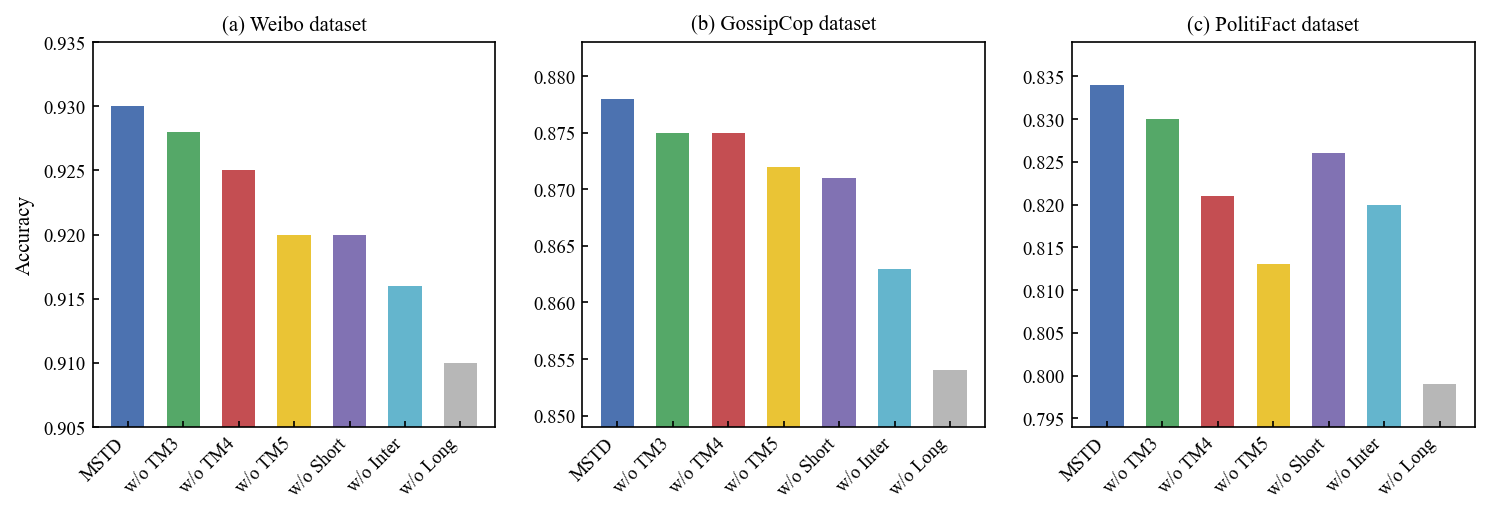

Figure saved to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_nature_TNR_big.png


In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序与配色 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o Inter',
    'long':  'w/o Long',
}

colors = ["#4C72B0", "#55A868", "#C44E52",
          "#EAC435", "#8172B3", "#64B5CD", "#B7B7B7"]

# ============ 3. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,          # 全局基础字体稍微调大
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,    # 轴标题略大
    'axes.titlesize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 4. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))  # 子图整体放大一点

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m, c in zip(method_order, colors):
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(c)

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=10)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset} dataset', fontsize=10)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout(w_pad=2.0, h_pad=0.8)
save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_nature_TNR_big.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)


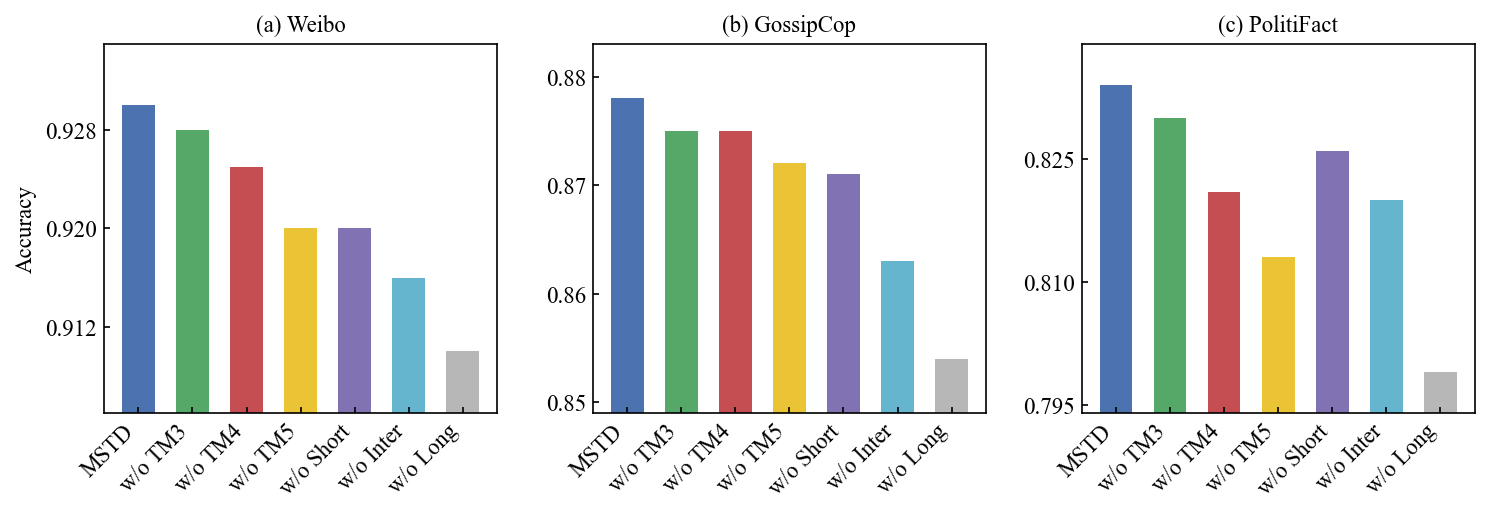

Figure saved to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_nature_TNR_big_sparseY.pdf


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # ★ 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序与配色 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o Inter',
    'long':  'w/o Long',
}

colors = ["#4C72B0", "#55A868", "#C44E52",
          "#EAC435", "#8172B3", "#64B5CD", "#B7B7B7"]

# ============ 3. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 4. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m, c in zip(method_order, colors):
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(c)

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=11)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=11)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    # ★ 控制 y 轴主刻度数量更稀疏一些，例如最多 4 个
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout(w_pad=2.0, h_pad=0.8)
# save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_nature_TNR_big_sparseY.pdf'
# plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)


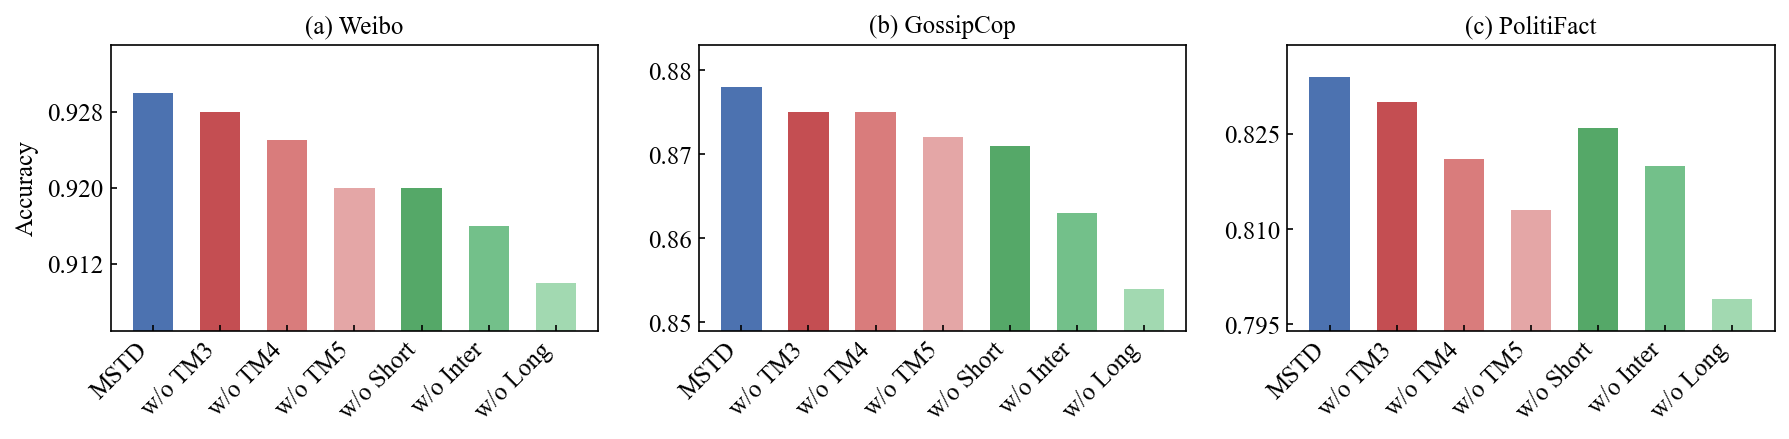

Figure saved to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\Fig9..pdf


In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

# x 轴显示用标签
label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o Inter',
    'long':  'w/o Long',
}

# ============ 3. 配色设计 ============
# MSTD：蓝色
# w/o TM3–TM5：同一红系由深到浅
# w/o Short–Long：同一绿系由深到浅
method_colors = {
    'MSTD':  '#4C72B0',  # 蓝

    '30off': '#C44E52',  # 深红
    '40off': '#D97C7C',  # 中红
    '50off': '#E4A6A6',  # 浅红

    'short': '#55A868',  # 深绿
    'inter': '#73C08A',  # 中绿
    'long':  '#A2D9B1',  # 浅绿
}

# ============ 4. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 5. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m in method_order:
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(method_colors[m])

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=12)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=12)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout(w_pad=2.0, h_pad=0.8)

save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\Fig9..pdf'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)


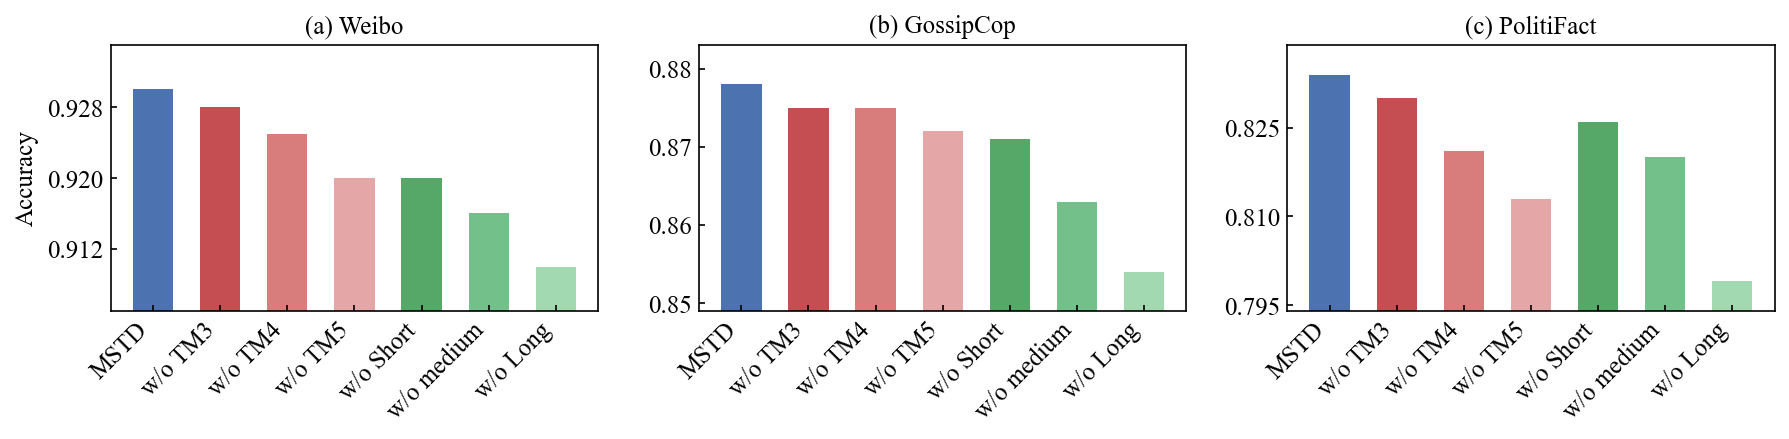

Figure saved to: C:\Users\Administrator\Desktop\人工智能\Fig9..pdf


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

# x 轴显示用标签
label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o medium',   # ← 这里改成 w/o medium
    'long':  'w/o Long',
}

# ============ 3. 配色设计 ============
# MSTD：蓝色
# w/o TM3–TM5：同一红系由深到浅
# w/o Short–Long：同一绿系由深到浅
method_colors = {
    'MSTD':  '#4C72B0',  # 蓝

    '30off': '#C44E52',  # 深红
    '40off': '#D97C7C',  # 中红
    '50off': '#E4A6A6',  # 浅红

    'short': '#55A868',  # 深绿
    'inter': '#73C08A',  # 中绿
    'long':  '#A2D9B1',  # 浅绿
}

# ============ 4. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 5. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m in method_order:
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(method_colors[m])

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=12)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=12)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout(w_pad=2.0, h_pad=0.8)

save_path = r'C:\Users\Administrator\Desktop\人工智能\Fig9..pdf'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)


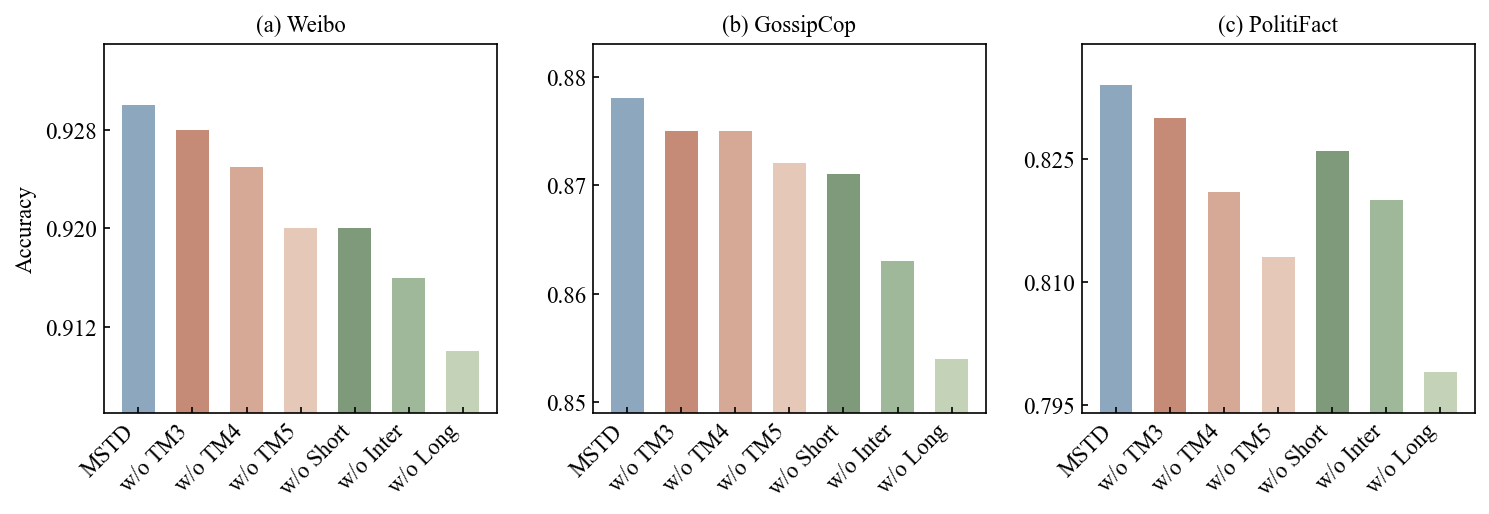

Figure saved to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_morandi.png


In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o Inter',
    'long':  'w/o Long',
}

# ============ 3. 莫兰迪风格配色 ============
# 整体偏灰、低饱和度
# MSTD：灰蓝
# w/o TM3–TM5：灰粉橘系 深→中→浅
# w/o Short–Long：灰绿系 深→中→浅
method_colors = {
    'MSTD':  '#8DA7BE',  # 灰蓝

    '30off': '#C58B76',  # 灰橘偏深
    '40off': '#D6A996',  # 灰橘中间
    '50off': '#E5C8B8',  # 灰橘偏浅

    'short': '#7F9A7A',  # 灰绿偏深
    'inter': '#A0B89A',  # 灰绿中间
    'long':  '#C4D3B7',  # 灰绿偏浅
}

# ============ 4. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 5. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m in method_order:
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(method_colors[m])

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=11)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=11)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout(w_pad=2.0, h_pad=0.8)

save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_morandi.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)


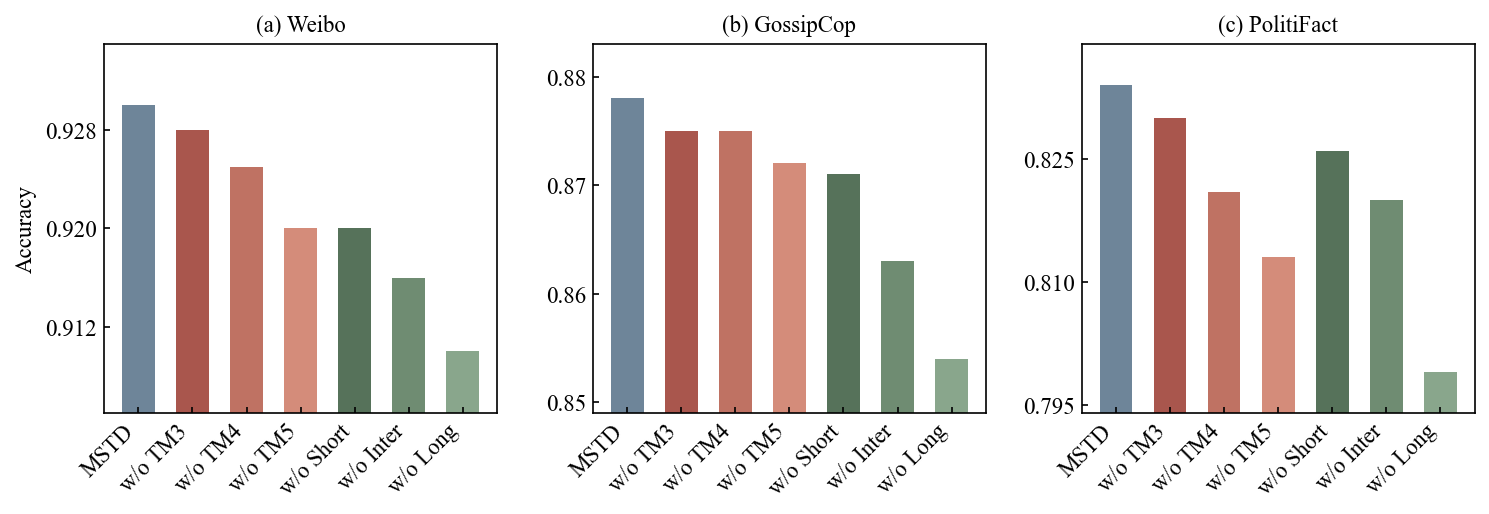

Figure saved to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_morandi_deeper.png


In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o Inter',
    'long':  'w/o Long',
}

# ============ 3. 莫兰迪风格配色（整体加深一档） ============
# MSTD：灰蓝（略深）
# w/o TM3–TM5：灰砖红系 深→中→浅
# w/o Short–Long：灰墨绿系 深→中→浅
method_colors = {
    'MSTD':  '#6E8599',  # 深一点的灰蓝

    '30off': '#A9564D',  # 深砖红
    '40off': '#BF7263',  # 中砖红
    '50off': '#D48C7A',  # 浅砖红

    'short': '#56725A',  # 深墨绿
    'inter': '#6F8C72',  # 中墨绿
    'long':  '#89A68C',  # 浅墨绿
}

# ============ 4. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 5. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m in method_order:
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(method_colors[m])

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=11)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=11)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout(w_pad=2.0, h_pad=0.8)

save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_morandi_deeper.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)


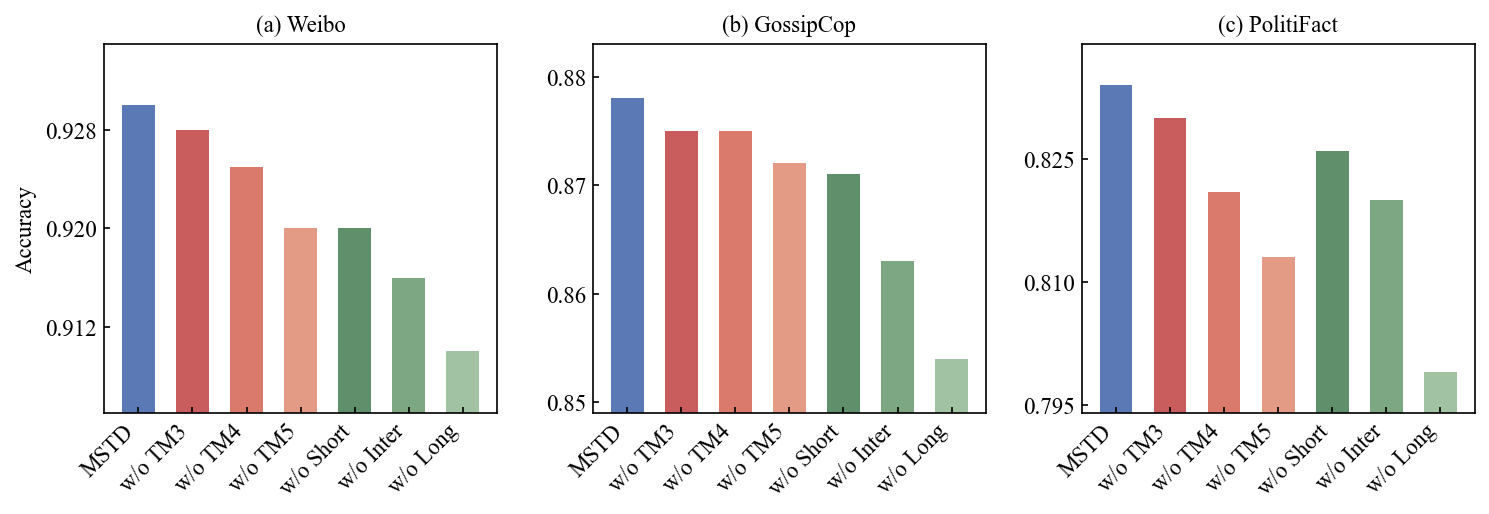

Figure saved to: E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_softSeries.png


In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 顺序与标签 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o Inter',
    'long':  'w/o Long',
}

# ============ 3. 配色：贴近你那张图的背景色系 ============
# MSTD：偏深中性蓝灰
# TM3–TM5：暖橘粉（和左侧粉区呼应），由深到浅
# Short–Long：柔和蓝（和中间蓝区/右侧浅色呼应），由深到浅
# ============ 3. 配色：由“蓝-红-绿”过渡 ============
method_colors = {
    # MSTD：主方法，用略偏灰的蓝色
    'MSTD':  '#5B79B5',   # 蓝

    # 模体阶数消融：偏红/橘的一组，深 -> 浅
    '30off': '#C95C5C',   # 深红橘
    '40off': '#D97A6C',   # 中红橘
    '50off': '#E39B85',   # 浅红橘

    # 时间尺度消融：偏绿的一组，深 -> 浅
    'short': '#5F8F6B',   # 深绿
    'inter': '#7DA783',   # 中绿
    'long':  '#A2C2A4',   # 浅绿
}


# ============ 4. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 5. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m in method_order:
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(method_colors[m])

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=11)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=11)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout(w_pad=2.0, h_pad=0.8)

save_path = r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\ablation_accuracy_3subplots_softSeries.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved to:", save_path)
